imports and config

In [ ]:
import os
import json
import zipfile
import gzip
import math
import random
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Change this if your files are in a different location
DATA_DIR = "."

ZIP_PATH = os.path.join(DATA_DIR, "Amazon_Fashion.zip")

REVIEWS_FILE = "Amazon_Fashion.jsonl"
META_FILE = "meta_Amazon_Fashion.jsonl"

# Main preprocessing controls
MIN_RATING = 4.0              # treat rating >= 4 as positive implicit feedback
USE_VERIFIED_ONLY = True      # improves signal quality
MIN_USER_INTERACTIONS = 3     # k-core user threshold
MIN_ITEM_INTERACTIONS = 3     # k-core item threshold

# Keep runtime small but project-quality reasonable
MAX_USERS = 8000             # reduce if your laptop is slow
MAX_ITEMS = 8000             # reduce if your laptop is slow

# Output folder
PROCESSED_DIR = "processed_amazon_fashion"
os.makedirs(PROCESSED_DIR, exist_ok=True)

In [ ]:
!pip install -q numpy pandas scipy scikit-learn networkx gensim tqdm matplotlib ipywidgets
!pip install -q lightfm-next
!pip install -q pyarrow

import torch
print(torch.__version__)
print(torch.cuda.is_available())


import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass


!pip install -q lightfm

try:
    from lightfm import LightFM
    print("LightFM installed successfully")
except Exception as e:
    print("LightFM failed:")
    print(e)

from google.colab import output
output.enable_custom_widget_manager()
print(1)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 3.7 MB/s eta 0:00:00
2.10.0+cpu
False
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for lightfm
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (lightfm)
LightFM installed successfully
1


In [ ]:
DATA_DIR = "/content"
PROCESSED_DIR = "/content/processed_amazon_fashion"
RESULTS_DIR = "/content/results"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


JSONL reader

In [ ]:
def open_jsonl_from_zip_or_file(zip_path, inner_file, direct_path=None):
    """
    Opens a JSONL file either directly from disk or from inside a zip file.
    """
    if direct_path is not None and os.path.exists(direct_path):
        return open(direct_path, "rt", encoding="utf-8")

    if os.path.exists(inner_file):
        return open(inner_file, "rt", encoding="utf-8")

    if os.path.exists(zip_path):
        zf = zipfile.ZipFile(zip_path)
        return zf.open(inner_file, "r")

    raise FileNotFoundError(
        f"Could not find {inner_file} directly or inside {zip_path}"
    )


def iter_jsonl(zip_path, inner_file, direct_path=None):
    """
    Memory-safe JSONL iterator.
    """
    f = open_jsonl_from_zip_or_file(zip_path, inner_file, direct_path)

    try:
        for line in f:
            if isinstance(line, bytes):
                line = line.decode("utf-8")
            if line.strip():
                yield json.loads(line)
    finally:
        f.close()

preview review and metadata records

In [ ]:
print("Review examples:")
for i, row in enumerate(iter_jsonl(ZIP_PATH, REVIEWS_FILE)):
    print(json.dumps(row, indent=2)[:1200])
    if i == 1:
        break

print("\nMetadata examples:")
for i, row in enumerate(iter_jsonl(ZIP_PATH, META_FILE)):
    print(json.dumps(row, indent=2)[:1200])
    if i == 1:
        break

Review examples:
{
  "rating": 5.0,
  "title": "Pretty locket",
  "text": "I think this locket is really pretty. The inside back is a solid silver depression and the front is a dome that is not solid (knotted). You could use it to store a small photo, lock of hair, etc but I use it when I need to carry medication with me. Closes securely. High quality & very pretty.",
  "images": [],
  "asin": "B00LOPVX74",
  "parent_asin": "B00LOPVX74",
  "user_id": "AGBFYI2DDIKXC5Y4FARTYDTQBMFQ",
  "timestamp": 1578528394489,
  "helpful_vote": 3,
  "verified_purchase": true
}
{
  "rating": 5.0,
  "title": "A",
  "text": "Great",
  "images": [],
  "asin": "B07B4JXK8D",
  "parent_asin": "B07B4JXK8D",
  "user_id": "AFQLNQNQYFWQZPJQZS6V3NZU4QBQ",
  "timestamp": 1608426246701,
  "helpful_vote": 0,
  "verified_purchase": true
}

Metadata examples:
{
  "main_category": "AMAZON FASHION",
  "title": "YUEDGE 5 Pairs Men's Moisture Control Cushioned Dry Fit Casual Athletic Crew Socks for Men (Blue, Size 9-12)",

load filtered interactions

In [ ]:
def load_interactions(
    zip_path=ZIP_PATH,
    reviews_file=REVIEWS_FILE,
    min_rating=MIN_RATING,
    verified_only=USE_VERIFIED_ONLY,
):
    rows = []

    needed_cols = [
        "user_id",
        "parent_asin",
        "asin",
        "rating",
        "timestamp",
        "verified_purchase",
        "helpful_vote",
    ]

    total = 0
    kept = 0

    for obj in tqdm(iter_jsonl(zip_path, reviews_file), desc="Reading reviews"):
        total += 1

        rating = obj.get("rating", None)
        if rating is None:
            continue

        if rating < min_rating:
            continue

        if verified_only and obj.get("verified_purchase", False) is not True:
            continue

        user_id = obj.get("user_id")
        item_id = obj.get("parent_asin") or obj.get("asin")
        timestamp = obj.get("timestamp")

        if user_id is None or item_id is None or timestamp is None:
            continue

        rows.append({
            "user_id": user_id,
            "item_id": item_id,
            "rating": float(rating),
            "timestamp": int(timestamp),
            "verified_purchase": bool(obj.get("verified_purchase", False)),
            "helpful_vote": int(obj.get("helpful_vote", 0) or 0),
        })
        kept += 1

    df = pd.DataFrame(rows)

    print(f"Total raw reviews scanned: {total:,}")
    print(f"Interactions kept after rating/verified filter: {kept:,}")
    print(f"Initial filtered shape: {df.shape}")

    return df


interactions = load_interactions()
interactions.head()

Reading reviews: 0it [00:00, ?it/s]

Total raw reviews scanned: 2,500,939
Interactions kept after rating/verified filter: 1,662,092
Initial filtered shape: (1662092, 6)


,user_id,item_id,rating,timestamp,verified_purchase,helpful_vote
0,AGBFYI2DDIKXC5Y4FARTYDTQBMFQ,B00LOPVX74,5.0,1578528394489,True,3
1,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,B07B4JXK8D,5.0,1608426246701,True,0
2,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,B00XESJTDE,5.0,1439476166000,True,0
3,AFWHJ6O3PV4JC7PVOJH6CPULO2KQ,B01MZDN9Z4,5.0,1497119249157,True,0
4,AEWJXW46LKSW22FWTGRYTLNE7TGA,B00N9X4XNU,4.0,1543584620566,True,0


deduplicate user-item pairs

In [ ]:
def deduplicate_interactions(df):
    before = len(df)

    df = df.sort_values(["user_id", "item_id", "timestamp"])
    df = df.drop_duplicates(["user_id", "item_id"], keep="last")
    df = df.sort_values(["user_id", "timestamp"]).reset_index(drop=True)

    after = len(df)

    print(f"Before deduplication: {before:,}")
    print(f"After deduplication:  {after:,}")
    print(f"Removed duplicates:   {before - after:,}")

    return df


interactions = deduplicate_interactions(interactions)
interactions.head()

Before deduplication: 1,662,092
After deduplication:  1,644,420
Removed duplicates:   17,672


,user_id,item_id,rating,timestamp,verified_purchase,helpful_vote
0,AE22236AFRRSMQIKGG7TPTB75QEA,B0722QNRPW,5.0,1611604554971,True,0
1,AE222GY2VH7MEWI4N5AHPXB5CP5A,B07C9Z1FTH,5.0,1561122965795,True,0
2,AE222H3FGXWLHRFUMGMS2RR57NDQ,B00925F8E2,4.0,1572960103317,True,0
3,AE222SFRFOAFCUJ3DKA3MVPDP3IA,B01N0A1PKC,5.0,1490312680000,True,1
4,AE2233IKA2327CVE7WFSJVHDTPOA,B003RRXWXU,5.0,1565212467361,True,0


inspect sparsity before filtering

In [ ]:
print("Before k-core:")
print(f"Interactions: {len(interactions):,}")
print(f"Users:        {interactions['user_id'].nunique():,}")
print(f"Items:        {interactions['item_id'].nunique():,}")

user_counts = interactions["user_id"].value_counts()
item_counts = interactions["item_id"].value_counts()

print("\nUser interaction count distribution:")
print(user_counts.describe())

print("\nItem interaction count distribution:")
print(item_counts.describe())

print("\nUsers with at least 3 interactions:", (user_counts >= 3).sum())
print("Users with at least 5 interactions:", (user_counts >= 5).sum())
print("Items with at least 3 interactions:", (item_counts >= 3).sum())
print("Items with at least 5 interactions:", (item_counts >= 5).sum())

Before k-core:
Interactions: 1,644,420
Users:        1,419,098
Items:        599,475

User interaction count distribution:
count    1.419098e+06
mean     1.158778e+00
std      5.703430e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      5.000000e+01
Name: count, dtype: float64

Item interaction count distribution:
count    599475.000000
mean          2.743100
std          16.712899
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max        5957.000000
Name: count, dtype: float64

Users with at least 3 interactions: 37661
Users with at least 5 interactions: 5640
Items with at least 3 interactions: 124568
Items with at least 5 interactions: 60165


adaptive filtering

In [ ]:
def adaptive_filter_for_recommender(
    df,
    min_user_interactions=3,
    min_item_interactions=3,
    max_users=8000,
    max_items=8000,
    seed=42
):
    df = df.copy()

    print("Starting adaptive filtering")
    print(f"Initial interactions: {len(df):,}")
    print(f"Initial users:        {df['user_id'].nunique():,}")
    print(f"Initial items:        {df['item_id'].nunique():,}")

    # Step 1: keep users with enough interactions for train/val/test
    user_counts = df["user_id"].value_counts()
    good_users = user_counts[user_counts >= min_user_interactions].index
    df = df[df["user_id"].isin(good_users)].copy()

    print("\nAfter user >= min interactions:")
    print(f"Interactions: {len(df):,}")
    print(f"Users:        {df['user_id'].nunique():,}")
    print(f"Items:        {df['item_id'].nunique():,}")

    # Step 2: keep reasonably common items
    item_counts = df["item_id"].value_counts()
    good_items = item_counts[item_counts >= min_item_interactions].index
    df = df[df["item_id"].isin(good_items)].copy()

    print("\nAfter item >= min interactions:")
    print(f"Interactions: {len(df):,}")
    print(f"Users:        {df['user_id'].nunique():,}")
    print(f"Items:        {df['item_id'].nunique():,}")

    # Step 3: after removing rare items, users may drop below 3 interactions
    user_counts = df["user_id"].value_counts()
    good_users = user_counts[user_counts >= min_user_interactions].index
    df = df[df["user_id"].isin(good_users)].copy()

    print("\nAfter final user cleanup:")
    print(f"Interactions: {len(df):,}")
    print(f"Users:        {df['user_id'].nunique():,}")
    print(f"Items:        {df['item_id'].nunique():,}")

    # Step 4: limit to top items to reduce runtime
    if df["item_id"].nunique() > max_items:
        top_items = df["item_id"].value_counts().head(max_items).index
        df = df[df["item_id"].isin(top_items)].copy()

        user_counts = df["user_id"].value_counts()
        good_users = user_counts[user_counts >= min_user_interactions].index
        df = df[df["user_id"].isin(good_users)].copy()

    print("\nAfter item cap:")
    print(f"Interactions: {len(df):,}")
    print(f"Users:        {df['user_id'].nunique():,}")
    print(f"Items:        {df['item_id'].nunique():,}")

    # Step 5: sample users if still too large
    if df["user_id"].nunique() > max_users:
        user_counts = df["user_id"].value_counts()

        # Prefer users with richer history
        candidate_users = user_counts[user_counts >= min_user_interactions].index.to_numpy()

        rng = np.random.default_rng(seed)
        sampled_users = rng.choice(
            candidate_users,
            size=max_users,
            replace=False
        )

        df = df[df["user_id"].isin(sampled_users)].copy()

    # Step 6: final cleanup
    user_counts = df["user_id"].value_counts()
    good_users = user_counts[user_counts >= min_user_interactions].index
    df = df[df["user_id"].isin(good_users)].copy()

    item_counts = df["item_id"].value_counts()
    good_items = item_counts[item_counts >= 2].index
    df = df[df["item_id"].isin(good_items)].copy()

    df = df.sort_values(["user_id", "timestamp"]).reset_index(drop=True)

    n_users = df["user_id"].nunique()
    n_items = df["item_id"].nunique()
    n_interactions = len(df)

    print("\nFinal filtered dataset:")
    print(f"Interactions: {n_interactions:,}")
    print(f"Users:        {n_users:,}")
    print(f"Items:        {n_items:,}")

    if n_users > 0 and n_items > 0:
        density = n_interactions / (n_users * n_items)
        print(f"Density:      {density:.8f}")
        print(f"Sparsity:     {1 - density:.8f}")
    else:
        print("Dataset is empty. Need weaker filtering.")

    return df


interactions = adaptive_filter_for_recommender(
    interactions,
    min_user_interactions=MIN_USER_INTERACTIONS,
    min_item_interactions=MIN_ITEM_INTERACTIONS,
    max_users=MAX_USERS,
    max_items=MAX_ITEMS,
    seed=SEED
)

interactions.head()

Starting adaptive filtering
Initial interactions: 1,644,420
Initial users:        1,419,098
Initial items:        599,475

After user >= min interactions:
Interactions: 139,735
Users:        37,661
Items:        102,127

After item >= min interactions:
Interactions: 33,971
Users:        21,474
Items:        6,445

After final user cleanup:
Interactions: 9,325
Users:        2,618
Items:        3,974

After item cap:
Interactions: 9,325
Users:        2,618
Items:        3,974

Final filtered dataset:
Interactions: 7,259
Users:        2,559
Items:        1,908
Density:      0.00148672
Sparsity:     0.99851328


,user_id,item_id,rating,timestamp,verified_purchase,helpful_vote
0,AE24SNDX7QHMBSAQYEXYWQW7KOEQ,B009WS3PK8,4.0,1455340439000,True,0
1,AE24SNDX7QHMBSAQYEXYWQW7KOEQ,B017I2JAMG,5.0,1455517607000,True,2
2,AE24SNDX7QHMBSAQYEXYWQW7KOEQ,B01HR9742S,5.0,1522103163404,True,0
3,AE274ELTNGUU6B3ZF7HUUJARXUIQ,B00VBA35MS,5.0,1475322112000,True,0
4,AE274ELTNGUU6B3ZF7HUUJARXUIQ,B00N9X8VHY,5.0,1475322186000,True,0


safety check

In [ ]:
if len(interactions) == 0:
    raise ValueError("Filtered dataset is empty. Reduce MIN_USER_INTERACTIONS or MIN_ITEM_INTERACTIONS.")

if interactions["user_id"].nunique() < 100:
    raise ValueError("Too few users. Filtering is still too strict.")

if interactions["item_id"].nunique() < 100:
    raise ValueError("Too few items. Filtering is still too strict.")

print("Dataset passed safety checks.")

Dataset passed safety checks.


ID encoding

In [ ]:
def encode_ids(df):
    df = df.copy()

    user_ids = sorted(df["user_id"].unique())
    item_ids = sorted(df["item_id"].unique())

    user2idx = {u: i for i, u in enumerate(user_ids)}
    item2idx = {item: i for i, item in enumerate(item_ids)}

    idx2user = {i: u for u, i in user2idx.items()}
    idx2item = {i: item for item, i in item2idx.items()}

    df["user_idx"] = df["user_id"].map(user2idx).astype("int32")
    df["item_idx"] = df["item_id"].map(item2idx).astype("int32")

    print(f"Encoded users: {len(user2idx):,}")
    print(f"Encoded items: {len(item2idx):,}")

    return df, user2idx, item2idx, idx2user, idx2item


interactions, user2idx, item2idx, idx2user, idx2item = encode_ids(interactions)

interactions.head()

Encoded users: 2,559
Encoded items: 1,908


,user_id,item_id,rating,timestamp,verified_purchase,helpful_vote,user_idx,item_idx
0,AE24SNDX7QHMBSAQYEXYWQW7KOEQ,B009WS3PK8,4.0,1455340439000,True,0,0,115
1,AE24SNDX7QHMBSAQYEXYWQW7KOEQ,B017I2JAMG,5.0,1455517607000,True,2,0,1055
2,AE24SNDX7QHMBSAQYEXYWQW7KOEQ,B01HR9742S,5.0,1522103163404,True,0,0,1392
3,AE274ELTNGUU6B3ZF7HUUJARXUIQ,B00VBA35MS,5.0,1475322112000,True,0,1,734
4,AE274ELTNGUU6B3ZF7HUUJARXUIQ,B00N9X8VHY,5.0,1475322186000,True,0,1,544


chronological train/validation/test split

In [ ]:
def chronological_leave_one_out_split(df):
    train_rows = []
    val_rows = []
    test_rows = []

    skipped_users = 0

    for user_idx, group in tqdm(df.groupby("user_idx"), desc="Splitting by user"):
        group = group.sort_values("timestamp")

        if len(group) < 3:
            skipped_users += 1
            continue

        train_rows.append(group.iloc[:-2])
        val_rows.append(group.iloc[-2:-1])
        test_rows.append(group.iloc[-1:])

    if len(train_rows) == 0:
        raise ValueError("No users had enough interactions for train/val/test split.")

    train_df = pd.concat(train_rows).reset_index(drop=True)
    val_df = pd.concat(val_rows).reset_index(drop=True)
    test_df = pd.concat(test_rows).reset_index(drop=True)

    print("Split sizes:")
    print(f"Train: {len(train_df):,}")
    print(f"Val:   {len(val_df):,}")
    print(f"Test:  {len(test_df):,}")
    print(f"Skipped users: {skipped_users:,}")

    print("\nUnique users:")
    print(f"Train users: {train_df['user_idx'].nunique():,}")
    print(f"Val users:   {val_df['user_idx'].nunique():,}")
    print(f"Test users:  {test_df['user_idx'].nunique():,}")

    print("\nUnique items:")
    print(f"Train items: {train_df['item_idx'].nunique():,}")
    print(f"Val items:   {val_df['item_idx'].nunique():,}")
    print(f"Test items:  {test_df['item_idx'].nunique():,}")

    return train_df, val_df, test_df


train_df, val_df, test_df = chronological_leave_one_out_split(interactions)

Splitting by user:   0%|          | 0/2559 [00:00<?, ?it/s]

Split sizes:
Train: 2,463
Val:   1,451
Test:  1,451
Skipped users: 1,108

Unique users:
Train users: 1,451
Val users:   1,451
Test users:  1,451

Unique items:
Train items: 1,095
Val items:   862
Test items:  902


filter validation/test to known train users and items

In [ ]:
def filter_eval_to_train_entities(train_df, val_df, test_df):
    train_users = set(train_df["user_idx"].unique())
    train_items = set(train_df["item_idx"].unique())

    before_val = len(val_df)
    before_test = len(test_df)

    val_df = val_df[
        val_df["user_idx"].isin(train_users) &
        val_df["item_idx"].isin(train_items)
    ].reset_index(drop=True)

    test_df = test_df[
        test_df["user_idx"].isin(train_users) &
        test_df["item_idx"].isin(train_items)
    ].reset_index(drop=True)

    print(f"Validation rows before/after: {before_val:,} -> {len(val_df):,}")
    print(f"Test rows before/after:       {before_test:,} -> {len(test_df):,}")

    if len(val_df) == 0 or len(test_df) == 0:
        print("Warning: validation or test became empty.")
        print("We may need to use a random split instead of chronological split.")

    return val_df, test_df


val_df, test_df = filter_eval_to_train_entities(train_df, val_df, test_df)

Validation rows before/after: 1,451 -> 1,011
Test rows before/after:       1,451 -> 898


load metadata for selected items

In [ ]:
def load_filtered_metadata(
    item2idx,
    zip_path=ZIP_PATH,
    meta_file=META_FILE,
):
    needed_items = set(item2idx.keys())
    rows = []
    scanned = 0
    kept = 0

    for obj in tqdm(iter_jsonl(zip_path, meta_file), desc="Reading metadata"):
        scanned += 1

        item_id = obj.get("parent_asin") or obj.get("asin")
        if item_id not in needed_items:
            continue

        title = obj.get("title", "")
        main_category = obj.get("main_category", "")
        average_rating = obj.get("average_rating", np.nan)
        rating_number = obj.get("rating_number", np.nan)
        price = obj.get("price", np.nan)

        features = obj.get("features", [])
        description = obj.get("description", [])
        categories = obj.get("categories", [])

        if isinstance(features, list):
            features_text = " ".join([str(x) for x in features])
        else:
            features_text = str(features)

        if isinstance(description, list):
            description_text = " ".join([str(x) for x in description])
        else:
            description_text = str(description)

        if isinstance(categories, list):
            categories_text = " ".join([str(x) for x in categories])
        else:
            categories_text = str(categories)

        text = " ".join([
            str(title),
            str(main_category),
            features_text,
            description_text,
            categories_text,
        ]).strip()

        rows.append({
            "item_id": item_id,
            "item_idx": item2idx[item_id],
            "title": title,
            "main_category": main_category,
            "average_rating": average_rating,
            "rating_number": rating_number,
            "price": price,
            "metadata_text": text,
        })
        kept += 1

    meta_df = pd.DataFrame(rows)

    print(f"Metadata records scanned: {scanned:,}")
    print(f"Metadata records kept:    {kept:,}")
    print(f"Metadata shape:           {meta_df.shape}")

    return meta_df


meta_df = load_filtered_metadata(item2idx)
meta_df.head()

Reading metadata: 0it [00:00, ?it/s]

Metadata records scanned: 826,108
Metadata records kept:    1,908
Metadata shape:           (1908, 8)


,item_id,item_idx,title,main_category,average_rating,rating_number,price,metadata_text
0,B00D4C1D7U,177,Gold Overlay with Navy Blue Mini Evil Eye Styl...,AMAZON FASHION,4.3,71,NaN,Gold Overlay with Navy Blue Mini Evil Eye Styl...
1,B0196HE9I6,1115,Missmay Women's Vintage Retro Plaid Patchwork ...,AMAZON FASHION,3.5,47,NaN,Missmay Women's Vintage Retro Plaid Patchwork ...
2,B07S8KMCQW,1816,icyzone Workout Tank Tops for Women - Running ...,AMAZON FASHION,4.5,6074,14.99,icyzone Workout Tank Tops for Women - Running ...
3,B00E3RD0GC,202,YAZILIND Gothic Lolita Sexy Lace Flower Cute B...,AMAZON FASHION,3.6,192,NaN,YAZILIND Gothic Lolita Sexy Lace Flower Cute B...
4,B0BVMLJTFS,1899,Aoxjox Women's High Waist Workout Gym Vital Se...,AMAZON FASHION,4.3,8754,26.99,Aoxjox Women's High Waist Workout Gym Vital Se...


final summary

In [ ]:
def dataset_summary(interactions, train_df, val_df, test_df, meta_df):
    n_users = interactions["user_idx"].nunique()
    n_items = interactions["item_idx"].nunique()
    n_interactions = len(interactions)

    density = n_interactions / (n_users * n_items)

    summary = {
        "Total interactions": n_interactions,
        "Users": n_users,
        "Items": n_items,
        "Density": density,
        "Sparsity": 1 - density,
        "Avg interactions/user": interactions.groupby("user_idx").size().mean(),
        "Median interactions/user": interactions.groupby("user_idx").size().median(),
        "Avg interactions/item": interactions.groupby("item_idx").size().mean(),
        "Median interactions/item": interactions.groupby("item_idx").size().median(),
        "Train interactions": len(train_df),
        "Validation interactions": len(val_df),
        "Test interactions": len(test_df),
        "Metadata items found": len(meta_df),
    }

    for k, v in summary.items():
        if isinstance(v, float):
            print(f"{k}: {v:.6f}")
        else:
            print(f"{k}: {v:,}")

    return summary


summary = dataset_summary(interactions, train_df, val_df, test_df, meta_df)

Total interactions: 7,259
Users: 2,559
Items: 1,908
Density: 0.001487
Sparsity: 0.998513
Avg interactions/user: 2.836655
Median interactions/user: 3.000000
Avg interactions/item: 3.804507
Median interactions/item: 2.000000
Train interactions: 2,463
Validation interactions: 1,011
Test interactions: 898
Metadata items found: 1,908


save everything

In [ ]:
train_df.to_csv(os.path.join(PROCESSED_DIR, "train.csv"), index=False)
val_df.to_csv(os.path.join(PROCESSED_DIR, "val.csv"), index=False)
test_df.to_csv(os.path.join(PROCESSED_DIR, "test.csv"), index=False)
interactions.to_csv(os.path.join(PROCESSED_DIR, "interactions.csv"), index=False)
meta_df.to_csv(os.path.join(PROCESSED_DIR, "metadata.csv"), index=False)

import pickle

with open(os.path.join(PROCESSED_DIR, "user2idx.pkl"), "wb") as f:
    pickle.dump(user2idx, f)

with open(os.path.join(PROCESSED_DIR, "item2idx.pkl"), "wb") as f:
    pickle.dump(item2idx, f)

with open(os.path.join(PROCESSED_DIR, "idx2user.pkl"), "wb") as f:
    pickle.dump(idx2user, f)

with open(os.path.join(PROCESSED_DIR, "idx2item.pkl"), "wb") as f:
    pickle.dump(idx2item, f)

print("Saved processed files to:", PROCESSED_DIR)
print(os.listdir(PROCESSED_DIR))

Saved processed files to: /content/processed_amazon_fashion
['idx2item.pkl', 'item2idx.pkl', 'user2idx.pkl', 'val.csv', 'interactions.csv', 'train.csv', 'idx2user.pkl', 'metadata.csv', 'test.csv']


reload test

In [ ]:
train_df = pd.read_csv(os.path.join(PROCESSED_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(PROCESSED_DIR, "val.csv"))
test_df = pd.read_csv(os.path.join(PROCESSED_DIR, "test.csv"))
interactions = pd.read_csv(os.path.join(PROCESSED_DIR, "interactions.csv"))
meta_df = pd.read_csv(os.path.join(PROCESSED_DIR, "metadata.csv"))

with open(os.path.join(PROCESSED_DIR, "user2idx.pkl"), "rb") as f:
    user2idx = pickle.load(f)

with open(os.path.join(PROCESSED_DIR, "item2idx.pkl"), "rb") as f:
    item2idx = pickle.load(f)

with open(os.path.join(PROCESSED_DIR, "idx2user.pkl"), "rb") as f:
    idx2user = pickle.load(f)

with open(os.path.join(PROCESSED_DIR, "idx2item.pkl"), "rb") as f:
    idx2item = pickle.load(f)

print("Reload successful.")
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)
print("Interactions:", interactions.shape)
print("Metadata:", meta_df.shape)

train_df.head()

Reload successful.
Train: (2463, 8)
Val: (1011, 8)
Test: (898, 8)
Interactions: (7259, 8)
Metadata: (1908, 8)


,user_id,item_id,rating,timestamp,verified_purchase,helpful_vote,user_idx,item_idx
0,AE24SNDX7QHMBSAQYEXYWQW7KOEQ,B009WS3PK8,4.0,1455340439000,True,0,0,115
1,AE2DEERUBZI3F25CI2Q277OZX5OA,B00KW4KR66,5.0,1418977507000,True,0,4,436
2,AE2G3UU46RXIEVEUCVSOYNHPU56Q,B00IYF4QSA,5.0,1420683525000,True,0,5,340
3,AE2HUO3MJCFQW4YCP4HPEUVJ72HQ,B00M1E4A7W,5.0,1424221151000,True,1,6,504
4,AE2JS7SBQ6RJZRKXIEQ4C6YBHCUA,B017U1FDM6,4.0,1480200847000,True,0,7,1066


Summary

In [ ]:
summary = dataset_summary(interactions, train_df, val_df, test_df, meta_df)

Total interactions: 7,259
Users: 2,559
Items: 1,908
Density: 0.001487
Sparsity: 0.998513
Avg interactions/user: 2.836655
Median interactions/user: 3.000000
Avg interactions/item: 3.804507
Median interactions/item: 2.000000
Train interactions: 2,463
Validation interactions: 1,011
Test interactions: 898
Metadata items found: 1,908


install/import model libraries

In [ ]:
%pip install scipy scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import math
import random
from collections import defaultdict, Counter

from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

prepare train user-item structures

In [ ]:
def build_user_item_sets(df):
    user_items = defaultdict(set)
    for row in df.itertuples(index=False):
        user_items[int(row.user_idx)].add(int(row.item_idx))
    return user_items


train_user_items = build_user_item_sets(train_df)
val_user_items = build_user_item_sets(val_df)
test_user_items = build_user_item_sets(test_df)

all_items = set(interactions["item_idx"].unique())
n_users = interactions["user_idx"].nunique()
n_items = interactions["item_idx"].nunique()

print(f"Users: {n_users:,}")
print(f"Items: {n_items:,}")
print(f"Train users: {len(train_user_items):,}")
print(f"Validation users: {len(val_user_items):,}")
print(f"Test users: {len(test_user_items):,}")

Users: 2,559
Items: 1,908
Train users: 1,451
Validation users: 1,011
Test users: 898


negative sampling for evaluation

In [ ]:
def sample_negative_items(
    user,
    positive_item,
    train_user_items,
    all_items,
    num_negatives=99,
    seed=42
):
    rng = np.random.default_rng(seed + int(user))

    seen_items = train_user_items.get(user, set())
    forbidden = set(seen_items)
    forbidden.add(positive_item)

    candidates = list(all_items - forbidden)

    if len(candidates) <= num_negatives:
        return candidates

    negatives = rng.choice(candidates, size=num_negatives, replace=False)
    return [int(x) for x in negatives]


def build_eval_cases(eval_df, train_user_items, all_items, num_negatives=99):
    eval_cases = []

    for row in eval_df.itertuples(index=False):
        user = int(row.user_idx)
        positive_item = int(row.item_idx)

        negatives = sample_negative_items(
            user=user,
            positive_item=positive_item,
            train_user_items=train_user_items,
            all_items=all_items,
            num_negatives=num_negatives,
            seed=SEED
        )

        candidate_items = [positive_item] + negatives

        eval_cases.append({
            "user": user,
            "positive_item": positive_item,
            "candidate_items": candidate_items
        })

    return eval_cases


val_cases = build_eval_cases(val_df, train_user_items, all_items, num_negatives=99)
test_cases = build_eval_cases(test_df, train_user_items, all_items, num_negatives=99)

print(f"Validation cases: {len(val_cases):,}")
print(f"Test cases: {len(test_cases):,}")
print("Example case:", val_cases[0])

Validation cases: 1,011
Test cases: 898
Example case: {'user': 4, 'positive_item': 165, 'candidate_items': [165, 1030, 858, 1459, 734, 398, 1640, 1130, 604, 443, 457, 251, 1296, 327, 1849, 357, 910, 122, 1396, 965, 299, 13, 721, 81, 1320, 611, 467, 1447, 1161, 864, 103, 1837, 194, 1475, 973, 365, 986, 139, 1355, 1328, 463, 1147, 1166, 490, 1717, 1223, 1145, 1466, 1048, 1861, 924, 1463, 354, 1187, 840, 1818, 640, 605, 879, 1685, 257, 453, 1369, 915, 1562, 1585, 496, 1686, 667, 1817, 1878, 1460, 336, 1372, 1530, 892, 1343, 300, 935, 1423, 1197, 429, 101, 1847, 1612, 28, 1896, 1786, 599, 154, 934, 1787, 848, 1699, 997, 1415, 1424, 1270, 857, 945]}


ranking metrics

In [ ]:
def evaluate_model(score_function, eval_cases, k_values=[5, 10, 20], model_name="model"):
    results = {
        "Model": model_name
    }

    metric_storage = {
        k: {
            "hit": [],
            "precision": [],
            "recall": [],
            "ndcg": [],
            "mrr": []
        }
        for k in k_values
    }

    for case in eval_cases:
        user = case["user"]
        positive_item = case["positive_item"]
        candidate_items = case["candidate_items"]

        scores = score_function(user, candidate_items)

        # Sort candidate items by score descending
        ranked_items = [
            item for item, score in sorted(
                zip(candidate_items, scores),
                key=lambda x: x[1],
                reverse=True
            )
        ]

        for k in k_values:
            top_k = ranked_items[:k]

            hit = 1 if positive_item in top_k else 0
            precision = hit / k
            recall = hit

            if hit:
                rank = top_k.index(positive_item) + 1
                ndcg = 1 / math.log2(rank + 1)
                mrr = 1 / rank
            else:
                ndcg = 0
                mrr = 0

            metric_storage[k]["hit"].append(hit)
            metric_storage[k]["precision"].append(precision)
            metric_storage[k]["recall"].append(recall)
            metric_storage[k]["ndcg"].append(ndcg)
            metric_storage[k]["mrr"].append(mrr)

    for k in k_values:
        results[f"HitRate@{k}"] = np.mean(metric_storage[k]["hit"])
        results[f"Precision@{k}"] = np.mean(metric_storage[k]["precision"])
        results[f"Recall@{k}"] = np.mean(metric_storage[k]["recall"])
        results[f"NDCG@{k}"] = np.mean(metric_storage[k]["ndcg"])
        results[f"MRR@{k}"] = np.mean(metric_storage[k]["mrr"])

    return results

Model 1 Popularity baseline

train popularity model

In [ ]:
class PopularityRecommender:
    def __init__(self):
        self.item_scores = None
        self.default_score = 0.0

    def fit(self, train_df, n_items):
        item_counts = train_df["item_idx"].value_counts()

        self.item_scores = np.zeros(n_items, dtype=np.float32)

        for item, count in item_counts.items():
            self.item_scores[int(item)] = float(count)

        # Normalize scores for stability
        max_score = self.item_scores.max()
        if max_score > 0:
            self.item_scores = self.item_scores / max_score

        return self

    def score(self, user, candidate_items):
        return np.array([self.item_scores[item] for item in candidate_items], dtype=np.float32)


pop_model = PopularityRecommender()
pop_model.fit(train_df, n_items)

print("Popularity model trained.")
print("Top 10 popular item indices:")
print(np.argsort(-pop_model.item_scores)[:10])

Popularity model trained.
Top 10 popular item indices:
[405 430 399 398 439 852 436 404 424 396]


evaluate popularity model

In [ ]:
pop_val_results = evaluate_model(
    score_function=pop_model.score,
    eval_cases=val_cases,
    k_values=[5, 10, 20],
    model_name="Popularity"
)

pop_test_results = evaluate_model(
    score_function=pop_model.score,
    eval_cases=test_cases,
    k_values=[5, 10, 20],
    model_name="Popularity"
)

print("Validation results:")
display(pd.DataFrame([pop_val_results]))

print("Test results:")
display(pd.DataFrame([pop_test_results]))

Validation results:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,Popularity,0.385757,0.077151,0.385757,0.273527,0.236499,0.531157,0.053116,0.531157,0.319963,0.255324,0.722057,0.036103,0.722057,0.36905,0.269216


Test results:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,Popularity,0.426503,0.085301,0.426503,0.294233,0.250891,0.553452,0.055345,0.553452,0.334864,0.267417,0.719376,0.035969,0.719376,0.377586,0.279541


Model 2 Item-based collaborative filtering

build sparse user-item matrix

In [ ]:
def build_sparse_user_item_matrix(train_df, n_users, n_items):
    rows = train_df["user_idx"].astype(int).values
    cols = train_df["item_idx"].astype(int).values
    data = np.ones(len(train_df), dtype=np.float32)

    matrix = csr_matrix(
        (data, (rows, cols)),
        shape=(n_users, n_items),
        dtype=np.float32
    )

    return matrix


train_matrix = build_sparse_user_item_matrix(train_df, n_users, n_items)

print("Train matrix shape:", train_matrix.shape)
print("Non-zero interactions:", train_matrix.nnz)
print("Density:", train_matrix.nnz / (train_matrix.shape[0] * train_matrix.shape[1]))

Train matrix shape: (2559, 1908)
Non-zero interactions: 2463
Density: 0.0005044472462464455


train item-based collaborative filtering

In [ ]:
class ItemBasedCF:
    def __init__(self, top_similar_items=100):
        self.top_similar_items = top_similar_items
        self.item_similarity = None
        self.train_user_items = None
        self.n_items = None

    def fit(self, train_matrix, train_user_items):
        self.train_user_items = train_user_items
        self.n_items = train_matrix.shape[1]

        # item-user matrix
        item_user_matrix = train_matrix.T

        print("Computing item-item cosine similarity...")
        similarity = cosine_similarity(item_user_matrix, dense_output=True)

        # Remove self similarity
        np.fill_diagonal(similarity, 0.0)

        self.item_similarity = similarity.astype(np.float32)

        print("Item-based CF trained.")
        print("Similarity matrix shape:", self.item_similarity.shape)

        return self

    def score(self, user, candidate_items):
        seen_items = list(self.train_user_items.get(user, []))

        if len(seen_items) == 0:
            return np.zeros(len(candidate_items), dtype=np.float32)

        scores = []

        for item in candidate_items:
            item = int(item)

            # Score candidate by average similarity to user's seen items
            sim_scores = self.item_similarity[item, seen_items]

            if len(sim_scores) == 0:
                score = 0.0
            else:
                # Use mean of positive similarities
                positive_sims = sim_scores[sim_scores > 0]
                if len(positive_sims) == 0:
                    score = 0.0
                else:
                    score = float(np.mean(positive_sims))

            scores.append(score)

        return np.array(scores, dtype=np.float32)


itemcf_model = ItemBasedCF(top_similar_items=100)
itemcf_model.fit(train_matrix, train_user_items)

Computing item-item cosine similarity...
Item-based CF trained.
Similarity matrix shape: (1908, 1908)


evaluate item-based collaborative filtering

In [ ]:
itemcf_val_results = evaluate_model(
    score_function=itemcf_model.score,
    eval_cases=val_cases,
    k_values=[5, 10, 20],
    model_name="Item-Based CF"
)

itemcf_test_results = evaluate_model(
    score_function=itemcf_model.score,
    eval_cases=test_cases,
    k_values=[5, 10, 20],
    model_name="Item-Based CF"
)

print("Validation results:")
display(pd.DataFrame([itemcf_val_results]))

print("Test results:")
display(pd.DataFrame([itemcf_test_results]))

Validation results:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,Item-Based CF,0.979228,0.195846,0.979228,0.835648,0.787438,1.0,0.1,1.0,0.842871,0.790718,1.0,0.05,1.0,0.842871,0.790718


Test results:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,Item-Based CF,0.976615,0.195323,0.976615,0.834909,0.787509,0.998886,0.099889,0.998886,0.842438,0.790804,1.0,0.05,1.0,0.842739,0.790896


compare models so far

In [ ]:
val_results = []
test_results = []

val_results.append(pop_val_results)
val_results.append(itemcf_val_results)

test_results.append(pop_test_results)
test_results.append(itemcf_test_results)

val_results_df = pd.DataFrame(val_results)
test_results_df = pd.DataFrame(test_results)

print("Validation comparison:")
display(val_results_df)

print("Test comparison:")
display(test_results_df)

Validation comparison:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,Popularity,0.385757,0.077151,0.385757,0.273527,0.236499,0.531157,0.053116,0.531157,0.319963,0.255324,0.722057,0.036103,0.722057,0.369050,0.269216
1,Item-Based CF,0.979228,0.195846,0.979228,0.835648,0.787438,1.000000,0.100000,1.000000,0.842871,0.790718,1.000000,0.050000,1.000000,0.842871,0.790718


Test comparison:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,Popularity,0.426503,0.085301,0.426503,0.294233,0.250891,0.553452,0.055345,0.553452,0.334864,0.267417,0.719376,0.035969,0.719376,0.377586,0.279541
1,Item-Based CF,0.976615,0.195323,0.976615,0.834909,0.787509,0.998886,0.099889,0.998886,0.842438,0.790804,1.000000,0.050000,1.000000,0.842739,0.790896


save current results

In [ ]:
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

val_results_df.to_csv(os.path.join(RESULTS_DIR, "validation_results_step1.csv"), index=False)
test_results_df.to_csv(os.path.join(RESULTS_DIR, "test_results_step1.csv"), index=False)

print("Saved results to:", RESULTS_DIR)
print(os.listdir(RESULTS_DIR))

Saved results to: results
['validation_results_step1.csv', 'test_results_step1.csv']


Model 3 User-Based Collaborative Filtering

train user-based collaborative filtering

In [ ]:
class UserBasedCF:
    def __init__(self):
        self.user_similarity = None
        self.train_matrix = None
        self.train_user_items = None

    def fit(self, train_matrix, train_user_items):
        self.train_matrix = train_matrix
        self.train_user_items = train_user_items

        print("Computing user-user cosine similarity...")
        similarity = cosine_similarity(train_matrix, dense_output=True)

        # Remove self similarity
        np.fill_diagonal(similarity, 0.0)

        self.user_similarity = similarity.astype(np.float32)

        print("User-based CF trained.")
        print("Similarity matrix shape:", self.user_similarity.shape)

        return self

    def score(self, user, candidate_items):
        user = int(user)
        candidate_items = [int(item) for item in candidate_items]

        # Similarity of this user to all other users
        sim_users = self.user_similarity[user]

        scores = []

        for item in candidate_items:
            # Users who interacted with this item
            item_column = self.train_matrix[:, item].toarray().ravel()

            # Weighted sum of similar users who interacted with item
            score = float(np.dot(sim_users, item_column))

            scores.append(score)

        return np.array(scores, dtype=np.float32)


usercf_model = UserBasedCF()
usercf_model.fit(train_matrix, train_user_items)

Computing user-user cosine similarity...
User-based CF trained.
Similarity matrix shape: (2559, 2559)


evaluate user-based collaborative filtering

In [ ]:
usercf_val_results = evaluate_model(
    score_function=usercf_model.score,
    eval_cases=val_cases,
    k_values=[5, 10, 20],
    model_name="User-Based CF"
)

usercf_test_results = evaluate_model(
    score_function=usercf_model.score,
    eval_cases=test_cases,
    k_values=[5, 10, 20],
    model_name="User-Based CF"
)

print("Validation results:")
display(pd.DataFrame([usercf_val_results]))

print("Test results:")
display(pd.DataFrame([usercf_test_results]))

Validation results:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,User-Based CF,0.986152,0.19723,0.986152,0.860698,0.818266,1.0,0.1,1.0,0.86554,0.820479,1.0,0.05,1.0,0.86554,0.820479


Test results:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,User-Based CF,0.981069,0.196214,0.981069,0.853082,0.810022,0.998886,0.099889,0.998886,0.859094,0.812647,1.0,0.05,1.0,0.859395,0.81274


Model 4 Matrix Factorization with TruncatedSVD

import SVD

In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

train SVD matrix factorization model

In [ ]:
class SVDRecommender:
    def __init__(self, n_components=32, random_state=42):
        self.n_components = n_components
        self.random_state = random_state
        self.svd = None
        self.user_factors = None
        self.item_factors = None
        self.train_user_items = None

    def fit(self, train_matrix, train_user_items):
        self.train_user_items = train_user_items

        max_components = min(
            self.n_components,
            train_matrix.shape[0] - 1,
            train_matrix.shape[1] - 1
        )

        print(f"Training TruncatedSVD with {max_components} components...")

        self.svd = TruncatedSVD(
            n_components=max_components,
            random_state=self.random_state
        )

        self.user_factors = self.svd.fit_transform(train_matrix)
        self.item_factors = self.svd.components_.T

        # Normalize factors so dot product behaves like cosine similarity
        self.user_factors = normalize(self.user_factors)
        self.item_factors = normalize(self.item_factors)

        print("SVD model trained.")
        print("User factors:", self.user_factors.shape)
        print("Item factors:", self.item_factors.shape)
        print("Explained variance ratio sum:", self.svd.explained_variance_ratio_.sum())

        return self

    def score(self, user, candidate_items):
        user = int(user)
        candidate_items = [int(item) for item in candidate_items]

        user_vector = self.user_factors[user]
        item_vectors = self.item_factors[candidate_items]

        scores = item_vectors @ user_vector

        return scores.astype(np.float32)


svd_model = SVDRecommender(n_components=32, random_state=SEED)
svd_model.fit(train_matrix, train_user_items)

Training TruncatedSVD with 32 components...
SVD model trained.
User factors: (2559, 32)
Item factors: (1908, 32)
Explained variance ratio sum: 0.2320125


evaluate SVD matrix factorization

In [ ]:
svd_val_results = evaluate_model(
    score_function=svd_model.score,
    eval_cases=val_cases,
    k_values=[5, 10, 20],
    model_name="Matrix Factorization SVD"
)

svd_test_results = evaluate_model(
    score_function=svd_model.score,
    eval_cases=test_cases,
    k_values=[5, 10, 20],
    model_name="Matrix Factorization SVD"
)

print("Validation results:")
display(pd.DataFrame([svd_val_results]))

print("Test results:")
display(pd.DataFrame([svd_test_results]))

Validation results:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,Matrix Factorization SVD,0.163205,0.032641,0.163205,0.112157,0.0955,0.275964,0.027596,0.275964,0.147891,0.10983,0.467854,0.023393,0.467854,0.195945,0.122773


Test results:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,Matrix Factorization SVD,0.142539,0.028508,0.142539,0.095263,0.079751,0.228285,0.022829,0.228285,0.122665,0.090878,0.416481,0.020824,0.416481,0.169811,0.103586


Model 5 Neural Matrix Factorization

import PyTorch

In [ ]:
%pip install torch

In [ ]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader

    print("PyTorch version:", torch.__version__)
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", DEVICE)

except ImportError:
    print("PyTorch not installed. Run the next install cell.")

PyTorch version: 2.10.0+cpu
Using device: cpu


build neural training dataset

In [ ]:
class InteractionDataset(Dataset):
    def __init__(
        self,
        train_df,
        train_user_items,
        all_items,
        num_negatives=4,
        seed=42
    ):
        self.users = []
        self.items = []
        self.labels = []

        rng = np.random.default_rng(seed)
        all_items_list = list(all_items)

        print("Building neural training examples...")

        for row in tqdm(train_df.itertuples(index=False), total=len(train_df)):
            user = int(row.user_idx)
            pos_item = int(row.item_idx)

            # positive example
            self.users.append(user)
            self.items.append(pos_item)
            self.labels.append(1.0)

            seen = train_user_items.get(user, set())

            # negative examples
            added = 0
            attempts = 0

            while added < num_negatives and attempts < num_negatives * 20:
                neg_item = int(rng.choice(all_items_list))
                attempts += 1

                if neg_item not in seen and neg_item != pos_item:
                    self.users.append(user)
                    self.items.append(neg_item)
                    self.labels.append(0.0)
                    added += 1

        self.users = torch.tensor(self.users, dtype=torch.long)
        self.items = torch.tensor(self.items, dtype=torch.long)
        self.labels = torch.tensor(self.labels, dtype=torch.float32)

        print("Training examples:", len(self.labels))
        print("Positive examples:", int(self.labels.sum().item()))
        print("Negative examples:", int((self.labels == 0).sum().item()))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx]


neural_train_dataset = InteractionDataset(
    train_df=train_df,
    train_user_items=train_user_items,
    all_items=all_items,
    num_negatives=4,
    seed=SEED
)

neural_train_loader = DataLoader(
    neural_train_dataset,
    batch_size=512,
    shuffle=True
)

Building neural training examples...


  0%|          | 0/2463 [00:00<?, ?it/s]

Training examples: 12315
Positive examples: 2463
Negative examples: 9852


define Neural Matrix Factorization model

In [ ]:
class NeuralMF(nn.Module):
    def __init__(self, n_users, n_items, embedding_dim=32, hidden_dims=[64, 32], dropout=0.2):
        super().__init__()

        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.item_embedding = nn.Embedding(n_items, embedding_dim)

        layers = []
        input_dim = embedding_dim * 2

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim

        layers.append(nn.Linear(input_dim, 1))

        self.mlp = nn.Sequential(*layers)

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.item_embedding.weight, std=0.01)

    def forward(self, users, items):
        user_vec = self.user_embedding(users)
        item_vec = self.item_embedding(items)

        x = torch.cat([user_vec, item_vec], dim=1)
        logits = self.mlp(x).squeeze(1)

        return logits


neural_model = NeuralMF(
    n_users=n_users,
    n_items=n_items,
    embedding_dim=32,
    hidden_dims=[64, 32],
    dropout=0.2
).to(DEVICE)

print(neural_model)

NeuralMF(
  (user_embedding): Embedding(2559, 32)
  (item_embedding): Embedding(1908, 32)
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


train NeuralMF

In [ ]:
def train_neural_model(
    model,
    train_loader,
    epochs=10,
    lr=0.001,
    weight_decay=1e-5,
    device=DEVICE
):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    model.train()

    history = []

    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        total_examples = 0

        for users, items, labels in train_loader:
            users = users.to(device)
            items = items.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(users, items)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_examples += batch_size

        avg_loss = total_loss / total_examples
        history.append(avg_loss)

        print(f"Epoch {epoch:02d} | Loss: {avg_loss:.6f}")

    return history


neural_history = train_neural_model(
    model=neural_model,
    train_loader=neural_train_loader,
    epochs=10,
    lr=0.001,
    weight_decay=1e-5,
    device=DEVICE
)

Epoch 01 | Loss: 0.716608
Epoch 02 | Loss: 0.653419
Epoch 03 | Loss: 0.531941
Epoch 04 | Loss: 0.445200
Epoch 05 | Loss: 0.400821
Epoch 06 | Loss: 0.380750
Epoch 07 | Loss: 0.372853
Epoch 08 | Loss: 0.365543
Epoch 09 | Loss: 0.358283
Epoch 10 | Loss: 0.351372


plot neural training loss

In [ ]:
%pip install matplotlib

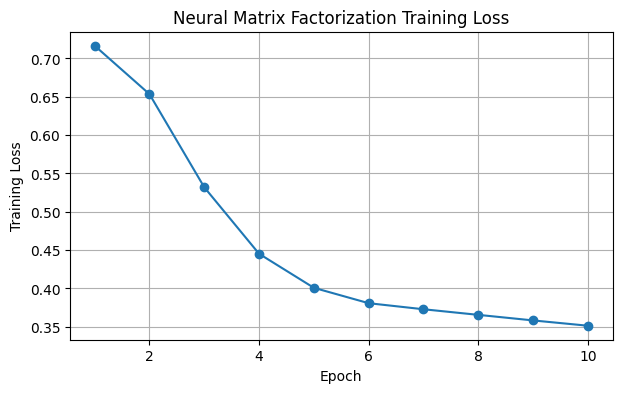

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(neural_history) + 1), neural_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Neural Matrix Factorization Training Loss")
plt.grid(True)
plt.show()

neural model scoring function

In [ ]:
class NeuralMFScorer:
    def __init__(self, model, device=DEVICE):
        self.model = model
        self.device = device
        self.model.eval()

    def score(self, user, candidate_items):
        user = int(user)
        candidate_items = [int(item) for item in candidate_items]

        users_tensor = torch.tensor(
            [user] * len(candidate_items),
            dtype=torch.long,
            device=self.device
        )

        items_tensor = torch.tensor(
            candidate_items,
            dtype=torch.long,
            device=self.device
        )

        with torch.no_grad():
            logits = self.model(users_tensor, items_tensor)
            scores = torch.sigmoid(logits).detach().cpu().numpy()

        return scores.astype(np.float32)


neural_scorer = NeuralMFScorer(neural_model, device=DEVICE)

evaluate NeuralMF

In [ ]:
neural_val_results = evaluate_model(
    score_function=neural_scorer.score,
    eval_cases=val_cases,
    k_values=[5, 10, 20],
    model_name="Neural Matrix Factorization"
)

neural_test_results = evaluate_model(
    score_function=neural_scorer.score,
    eval_cases=test_cases,
    k_values=[5, 10, 20],
    model_name="Neural Matrix Factorization"
)

print("Validation results:")
display(pd.DataFrame([neural_val_results]))

print("Test results:")
display(pd.DataFrame([neural_test_results]))

Validation results:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,Neural Matrix Factorization,0.319486,0.063897,0.319486,0.227406,0.196934,0.434224,0.043422,0.434224,0.263607,0.211349,0.586548,0.029327,0.586548,0.301541,0.221462


Test results:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,Neural Matrix Factorization,0.325167,0.065033,0.325167,0.23313,0.20284,0.452116,0.045212,0.452116,0.274119,0.219725,0.615813,0.030791,0.615813,0.315228,0.23087


update comparison table

In [ ]:
val_results.append(usercf_val_results)
val_results.append(svd_val_results)
val_results.append(neural_val_results)

test_results.append(usercf_test_results)
test_results.append(svd_test_results)
test_results.append(neural_test_results)

val_results_df = pd.DataFrame(val_results)
test_results_df = pd.DataFrame(test_results)

print("Validation comparison:")
display(val_results_df)

print("Test comparison:")
display(test_results_df)

Validation comparison:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,Popularity,0.385757,0.077151,0.385757,0.273527,0.236499,0.531157,0.053116,0.531157,0.319963,0.255324,0.722057,0.036103,0.722057,0.369050,0.269216
1,Item-Based CF,0.979228,0.195846,0.979228,0.835648,0.787438,1.000000,0.100000,1.000000,0.842871,0.790718,1.000000,0.050000,1.000000,0.842871,0.790718
2,User-Based CF,0.986152,0.197230,0.986152,0.860698,0.818266,1.000000,0.100000,1.000000,0.865540,0.820479,1.000000,0.050000,1.000000,0.865540,0.820479
3,Matrix Factorization SVD,0.163205,0.032641,0.163205,0.112157,0.095500,0.275964,0.027596,0.275964,0.147891,0.109830,0.467854,0.023393,0.467854,0.195945,0.122773
4,Neural Matrix Factorization,0.319486,0.063897,0.319486,0.227406,0.196934,0.434224,0.043422,0.434224,0.263607,0.211349,0.586548,0.029327,0.586548,0.301541,0.221462


Test comparison:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,Popularity,0.426503,0.085301,0.426503,0.294233,0.250891,0.553452,0.055345,0.553452,0.334864,0.267417,0.719376,0.035969,0.719376,0.377586,0.279541
1,Item-Based CF,0.976615,0.195323,0.976615,0.834909,0.787509,0.998886,0.099889,0.998886,0.842438,0.790804,1.000000,0.050000,1.000000,0.842739,0.790896
2,User-Based CF,0.981069,0.196214,0.981069,0.853082,0.810022,0.998886,0.099889,0.998886,0.859094,0.812647,1.000000,0.050000,1.000000,0.859395,0.812740
3,Matrix Factorization SVD,0.142539,0.028508,0.142539,0.095263,0.079751,0.228285,0.022829,0.228285,0.122665,0.090878,0.416481,0.020824,0.416481,0.169811,0.103586
4,Neural Matrix Factorization,0.325167,0.065033,0.325167,0.233130,0.202840,0.452116,0.045212,0.452116,0.274119,0.219725,0.615813,0.030791,0.615813,0.315228,0.230870


save updated results

In [ ]:
val_results_df.to_csv(os.path.join(RESULTS_DIR, "validation_results_step2.csv"), index=False)
test_results_df.to_csv(os.path.join(RESULTS_DIR, "test_results_step2.csv"), index=False)

print("Saved updated results.")
print(os.listdir(RESULTS_DIR))

Saved updated results.
['validation_results_step1.csv', 'validation_results_step2.csv', 'test_results_step1.csv', 'test_results_step2.csv']


Model 6 Graph Embedding Recommender

imports

In [ ]:
%pip install gensim networkx

In [ ]:
import networkx as nx

try:
    from gensim.models import Word2Vec
    print("gensim available")
except ImportError:
    print("Run: %pip install gensim")

gensim available


build user-item graph

In [ ]:
def build_user_item_graph(train_df):
    G = nx.Graph()

    for row in train_df.itertuples(index=False):
        user_node = f"u_{int(row.user_idx)}"
        item_node = f"i_{int(row.item_idx)}"

        G.add_node(user_node, node_type="user")
        G.add_node(item_node, node_type="item")
        G.add_edge(user_node, item_node)

    print("Graph built")
    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    return G


ui_graph = build_user_item_graph(train_df)

Graph built
Nodes: 2546
Edges: 2463


random walks

In [ ]:
def generate_random_walks(G, num_walks=20, walk_length=12, seed=42):
    rng = random.Random(seed)
    nodes = list(G.nodes())
    walks = []

    print("Generating random walks...")

    for _ in tqdm(range(num_walks), desc="Walk rounds"):
        rng.shuffle(nodes)

        for start_node in nodes:
            walk = [start_node]
            current = start_node

            for _ in range(walk_length - 1):
                neighbors = list(G.neighbors(current))
                if not neighbors:
                    break

                current = rng.choice(neighbors)
                walk.append(current)

            walks.append(walk)

    print("Random walks:", len(walks))
    return walks


walks = generate_random_walks(
    ui_graph,
    num_walks=20,
    walk_length=12,
    seed=SEED
)

Generating random walks...


Walk rounds:   0%|          | 0/20 [00:00<?, ?it/s]

Random walks: 50920


train graph embeddings

In [ ]:
graph_w2v = Word2Vec(
    sentences=walks,
    vector_size=32,
    window=5,
    min_count=1,
    sg=1,
    workers=4,
    epochs=10,
    seed=SEED
)

print("Graph embedding model trained.")
print("Vocabulary size:", len(graph_w2v.wv))

Graph embedding model trained.
Vocabulary size: 2546


graph recommender scorer

In [ ]:
class GraphEmbeddingRecommender:
    def __init__(self, w2v_model):
        self.w2v_model = w2v_model

    def score(self, user, candidate_items):
        user_node = f"u_{int(user)}"

        scores = []

        if user_node not in self.w2v_model.wv:
            return np.zeros(len(candidate_items), dtype=np.float32)

        user_vec = self.w2v_model.wv[user_node]

        for item in candidate_items:
            item_node = f"i_{int(item)}"

            if item_node not in self.w2v_model.wv:
                scores.append(0.0)
                continue

            item_vec = self.w2v_model.wv[item_node]

            denom = np.linalg.norm(user_vec) * np.linalg.norm(item_vec)
            if denom == 0:
                score = 0.0
            else:
                score = float(np.dot(user_vec, item_vec) / denom)

            scores.append(score)

        return np.array(scores, dtype=np.float32)


graph_model = GraphEmbeddingRecommender(graph_w2v)

evaluate graph embeddings

In [ ]:
graph_val_results = evaluate_model(
    score_function=graph_model.score,
    eval_cases=val_cases,
    k_values=[5, 10, 20],
    model_name="Graph Embeddings"
)

graph_test_results = evaluate_model(
    score_function=graph_model.score,
    eval_cases=test_cases,
    k_values=[5, 10, 20],
    model_name="Graph Embeddings"
)

print("Validation results:")
display(pd.DataFrame([graph_val_results]))

print("Test results:")
display(pd.DataFrame([graph_test_results]))

Validation results:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,Graph Embeddings,0.220574,0.044115,0.220574,0.147832,0.123788,0.336301,0.03363,0.336301,0.185068,0.139049,0.479723,0.023986,0.479723,0.221152,0.148853


Test results:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,Graph Embeddings,0.206013,0.041203,0.206013,0.134592,0.111099,0.297327,0.029733,0.297327,0.164093,0.123259,0.477728,0.023886,0.477728,0.20913,0.135321


final comparison table

In [ ]:
val_results.append(graph_val_results)
test_results.append(graph_test_results)

val_results_df = pd.DataFrame(val_results)
test_results_df = pd.DataFrame(test_results)

print("Final validation comparison:")
display(val_results_df)

print("Final test comparison:")
display(test_results_df)

Final validation comparison:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,Popularity,0.385757,0.077151,0.385757,0.273527,0.236499,0.531157,0.053116,0.531157,0.319963,0.255324,0.722057,0.036103,0.722057,0.369050,0.269216
1,Item-Based CF,0.979228,0.195846,0.979228,0.835648,0.787438,1.000000,0.100000,1.000000,0.842871,0.790718,1.000000,0.050000,1.000000,0.842871,0.790718
2,User-Based CF,0.986152,0.197230,0.986152,0.860698,0.818266,1.000000,0.100000,1.000000,0.865540,0.820479,1.000000,0.050000,1.000000,0.865540,0.820479
3,Matrix Factorization SVD,0.163205,0.032641,0.163205,0.112157,0.095500,0.275964,0.027596,0.275964,0.147891,0.109830,0.467854,0.023393,0.467854,0.195945,0.122773
4,Neural Matrix Factorization,0.319486,0.063897,0.319486,0.227406,0.196934,0.434224,0.043422,0.434224,0.263607,0.211349,0.586548,0.029327,0.586548,0.301541,0.221462
5,Graph Embeddings,0.220574,0.044115,0.220574,0.147832,0.123788,0.336301,0.033630,0.336301,0.185068,0.139049,0.479723,0.023986,0.479723,0.221152,0.148853


Final test comparison:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,Popularity,0.426503,0.085301,0.426503,0.294233,0.250891,0.553452,0.055345,0.553452,0.334864,0.267417,0.719376,0.035969,0.719376,0.377586,0.279541
1,Item-Based CF,0.976615,0.195323,0.976615,0.834909,0.787509,0.998886,0.099889,0.998886,0.842438,0.790804,1.000000,0.050000,1.000000,0.842739,0.790896
2,User-Based CF,0.981069,0.196214,0.981069,0.853082,0.810022,0.998886,0.099889,0.998886,0.859094,0.812647,1.000000,0.050000,1.000000,0.859395,0.812740
3,Matrix Factorization SVD,0.142539,0.028508,0.142539,0.095263,0.079751,0.228285,0.022829,0.228285,0.122665,0.090878,0.416481,0.020824,0.416481,0.169811,0.103586
4,Neural Matrix Factorization,0.325167,0.065033,0.325167,0.233130,0.202840,0.452116,0.045212,0.452116,0.274119,0.219725,0.615813,0.030791,0.615813,0.315228,0.230870
5,Graph Embeddings,0.206013,0.041203,0.206013,0.134592,0.111099,0.297327,0.029733,0.297327,0.164093,0.123259,0.477728,0.023886,0.477728,0.209130,0.135321


save final results

In [ ]:
val_results_df.to_csv(os.path.join(RESULTS_DIR, "final_validation_results.csv"), index=False)
test_results_df.to_csv(os.path.join(RESULTS_DIR, "final_test_results.csv"), index=False)

print("Saved final result files:")
print(os.listdir(RESULTS_DIR))

Saved final result files:
['final_test_results.csv', 'validation_results_step1.csv', 'validation_results_step2.csv', 'test_results_step1.csv', 'test_results_step2.csv', 'final_validation_results.csv']


Fix evaluation tie bias

rebuild evaluation cases with shuffled candidates

In [ ]:
def build_eval_cases_shuffled(eval_df, train_user_items, all_items, num_negatives=99, seed=42):
    eval_cases = []

    for row in eval_df.itertuples(index=False):
        user = int(row.user_idx)
        positive_item = int(row.item_idx)

        negatives = sample_negative_items(
            user=user,
            positive_item=positive_item,
            train_user_items=train_user_items,
            all_items=all_items,
            num_negatives=num_negatives,
            seed=seed
        )

        candidate_items = [positive_item] + negatives

        # Important: shuffle candidates so the positive item is not always first
        rng = np.random.default_rng(seed + user + positive_item)
        rng.shuffle(candidate_items)

        eval_cases.append({
            "user": user,
            "positive_item": positive_item,
            "candidate_items": candidate_items
        })

    return eval_cases


val_cases = build_eval_cases_shuffled(
    val_df,
    train_user_items,
    all_items,
    num_negatives=99,
    seed=SEED
)

test_cases = build_eval_cases_shuffled(
    test_df,
    train_user_items,
    all_items,
    num_negatives=99,
    seed=SEED
)

print(f"Validation cases: {len(val_cases):,}")
print(f"Test cases: {len(test_cases):,}")

print("Example shuffled case:")
print(val_cases[0])

Validation cases: 1,011
Test cases: 898
Example shuffled case:
{'user': 4, 'positive_item': 165, 'candidate_items': [1699, 467, 1686, 443, 327, 165, 1424, 457, 973, 300, 251, 1415, 139, 986, 734, 354, 1460, 857, 299, 1466, 935, 1197, 879, 1717, 398, 336, 1130, 1837, 910, 1423, 1818, 640, 915, 605, 965, 463, 1147, 1878, 1187, 154, 924, 1270, 1787, 1343, 1530, 599, 194, 1048, 1369, 858, 101, 721, 1320, 848, 490, 81, 1847, 1861, 1328, 28, 1396, 1562, 365, 1223, 1463, 496, 257, 864, 1849, 1786, 1640, 103, 122, 429, 1459, 1475, 1447, 13, 357, 1817, 1372, 1685, 1161, 1145, 1896, 453, 1166, 667, 997, 1585, 1296, 1355, 611, 840, 1612, 604, 945, 934, 1030, 892]}


replace evaluation function with random tie-breaking

In [ ]:
def evaluate_model(score_function, eval_cases, k_values=[5, 10, 20], model_name="model", seed=42):
    results = {
        "Model": model_name
    }

    metric_storage = {
        k: {
            "hit": [],
            "precision": [],
            "recall": [],
            "ndcg": [],
            "mrr": []
        }
        for k in k_values
    }

    for case_idx, case in enumerate(eval_cases):
        user = case["user"]
        positive_item = case["positive_item"]
        candidate_items = case["candidate_items"]

        scores = np.array(score_function(user, candidate_items), dtype=np.float64)

        # Tiny deterministic noise for fair random tie-breaking
        rng = np.random.default_rng(seed + case_idx)
        scores = scores + rng.normal(0, 1e-10, size=len(scores))

        ranked_items = [
            item for item, score in sorted(
                zip(candidate_items, scores),
                key=lambda x: x[1],
                reverse=True
            )
        ]

        for k in k_values:
            top_k = ranked_items[:k]

            hit = 1 if positive_item in top_k else 0
            precision = hit / k
            recall = hit

            if hit:
                rank = top_k.index(positive_item) + 1
                ndcg = 1 / math.log2(rank + 1)
                mrr = 1 / rank
            else:
                ndcg = 0
                mrr = 0

            metric_storage[k]["hit"].append(hit)
            metric_storage[k]["precision"].append(precision)
            metric_storage[k]["recall"].append(recall)
            metric_storage[k]["ndcg"].append(ndcg)
            metric_storage[k]["mrr"].append(mrr)

    for k in k_values:
        results[f"HitRate@{k}"] = np.mean(metric_storage[k]["hit"])
        results[f"Precision@{k}"] = np.mean(metric_storage[k]["precision"])
        results[f"Recall@{k}"] = np.mean(metric_storage[k]["recall"])
        results[f"NDCG@{k}"] = np.mean(metric_storage[k]["ndcg"])
        results[f"MRR@{k}"] = np.mean(metric_storage[k]["mrr"])

    return results

Rerun all final evaluations fairly

rerun validation and test evaluation for all 6 models

In [ ]:
fair_val_results = []
fair_test_results = []

models_to_evaluate = [
    ("Popularity", pop_model.score),
    ("Item-Based CF", itemcf_model.score),
    ("User-Based CF", usercf_model.score),
    ("Matrix Factorization SVD", svd_model.score),
    ("Neural Matrix Factorization", neural_scorer.score),
    ("Graph Embeddings", graph_model.score),
]

for model_name, score_function in models_to_evaluate:
    print(f"Evaluating {model_name}...")

    val_result = evaluate_model(
        score_function=score_function,
        eval_cases=val_cases,
        k_values=[5, 10, 20],
        model_name=model_name,
        seed=SEED
    )

    test_result = evaluate_model(
        score_function=score_function,
        eval_cases=test_cases,
        k_values=[5, 10, 20],
        model_name=model_name,
        seed=SEED
    )

    fair_val_results.append(val_result)
    fair_test_results.append(test_result)

fair_val_results_df = pd.DataFrame(fair_val_results)
fair_test_results_df = pd.DataFrame(fair_test_results)

print("Fair validation comparison:")
display(fair_val_results_df)

print("Fair test comparison:")
display(fair_test_results_df)

Evaluating Popularity...
Evaluating Item-Based CF...
Evaluating User-Based CF...
Evaluating Matrix Factorization SVD...
Evaluating Neural Matrix Factorization...
Evaluating Graph Embeddings...
Fair validation comparison:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,Popularity,0.361029,0.072206,0.361029,0.254986,0.219931,0.464886,0.046489,0.464886,0.288332,0.233547,0.620178,0.031009,0.620178,0.327324,0.244112
1,Item-Based CF,0.195846,0.039169,0.195846,0.132659,0.111985,0.239367,0.023937,0.239367,0.146751,0.117808,0.330366,0.016518,0.330366,0.169631,0.124030
2,User-Based CF,0.202770,0.040554,0.202770,0.154694,0.138757,0.239367,0.023937,0.239367,0.166404,0.143515,0.330366,0.016518,0.330366,0.189285,0.149736
3,Matrix Factorization SVD,0.163205,0.032641,0.163205,0.111749,0.094955,0.274975,0.027498,0.274975,0.147182,0.109174,0.461919,0.023096,0.461919,0.194129,0.121886
4,Neural Matrix Factorization,0.319486,0.063897,0.319486,0.227406,0.196934,0.434224,0.043422,0.434224,0.263607,0.211349,0.586548,0.029327,0.586548,0.301541,0.221462
5,Graph Embeddings,0.220574,0.044115,0.220574,0.147832,0.123788,0.336301,0.033630,0.336301,0.185068,0.139049,0.479723,0.023986,0.479723,0.221152,0.148853


Fair test comparison:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,Popularity,0.380846,0.076169,0.380846,0.267501,0.230252,0.494432,0.049443,0.494432,0.303916,0.245091,0.614699,0.030735,0.614699,0.334207,0.253336
1,Item-Based CF,0.172606,0.034521,0.172606,0.123951,0.107962,0.207127,0.020713,0.207127,0.135166,0.112623,0.292873,0.014644,0.292873,0.156482,0.118281
2,User-Based CF,0.177060,0.035412,0.177060,0.139492,0.126912,0.207127,0.020713,0.207127,0.149211,0.130923,0.292873,0.014644,0.292873,0.170526,0.136581
3,Matrix Factorization SVD,0.142539,0.028508,0.142539,0.095117,0.079566,0.228285,0.022829,0.228285,0.122519,0.090693,0.412027,0.020601,0.412027,0.168617,0.103153
4,Neural Matrix Factorization,0.325167,0.065033,0.325167,0.233130,0.202840,0.452116,0.045212,0.452116,0.274119,0.219725,0.615813,0.030791,0.615813,0.315228,0.230870
5,Graph Embeddings,0.206013,0.041203,0.206013,0.134592,0.111099,0.297327,0.029733,0.297327,0.164093,0.123259,0.477728,0.023886,0.477728,0.209130,0.135321


save corrected final results

In [ ]:
fair_val_results_df.to_csv(os.path.join(RESULTS_DIR, "fair_final_validation_results.csv"), index=False)
fair_test_results_df.to_csv(os.path.join(RESULTS_DIR, "fair_final_test_results.csv"), index=False)

print("Saved corrected final results:")
print(os.listdir(RESULTS_DIR))

Saved corrected final results:
['final_test_results.csv', 'validation_results_step1.csv', 'fair_final_validation_results.csv', 'validation_results_step2.csv', 'fair_final_test_results.csv', 'test_results_step1.csv', 'test_results_step2.csv', 'final_validation_results.csv']


plot HitRate@10 comparison

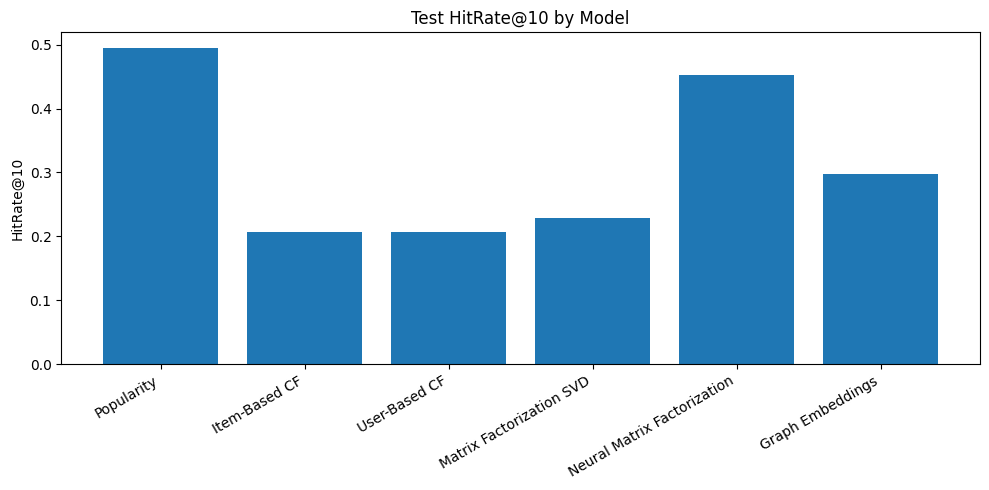

In [ ]:
import matplotlib.pyplot as plt

plot_df = fair_test_results_df[["Model", "HitRate@10", "NDCG@10", "MRR@10"]].copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["Model"], plot_df["HitRate@10"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("HitRate@10")
plt.title("Test HitRate@10 by Model")
plt.tight_layout()
plt.show()

plot NDCG@10 comparison

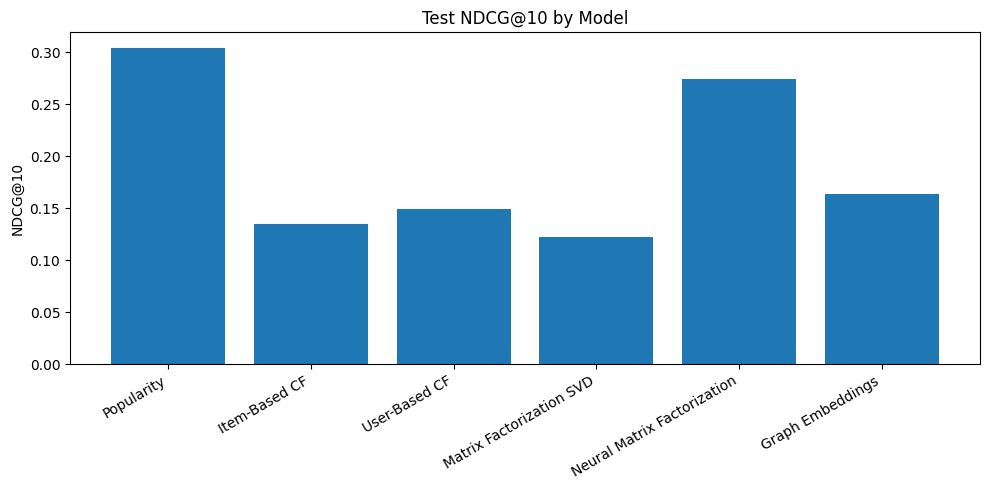

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(plot_df["Model"], plot_df["NDCG@10"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("NDCG@10")
plt.title("Test NDCG@10 by Model")
plt.tight_layout()
plt.show()

compact final results table

In [ ]:
compact_test_results = fair_test_results_df[
    [
        "Model",
        "HitRate@5",
        "HitRate@10",
        "HitRate@20",
        "NDCG@10",
        "MRR@10",
    ]
].copy()

compact_test_results = compact_test_results.sort_values(
    by="HitRate@10",
    ascending=False
).reset_index(drop=True)

display(compact_test_results)

compact_test_results.to_csv(
    os.path.join(RESULTS_DIR, "compact_fair_test_results.csv"),
    index=False
)

,Model,HitRate@5,HitRate@10,HitRate@20,NDCG@10,MRR@10
0,Popularity,0.380846,0.494432,0.614699,0.303916,0.245091
1,Neural Matrix Factorization,0.325167,0.452116,0.615813,0.274119,0.219725
2,Graph Embeddings,0.206013,0.297327,0.477728,0.164093,0.123259
3,Matrix Factorization SVD,0.142539,0.228285,0.412027,0.122519,0.090693
4,Item-Based CF,0.172606,0.207127,0.292873,0.135166,0.112623
5,User-Based CF,0.177060,0.207127,0.292873,0.149211,0.130923


final “best model” summary

In [ ]:
best_by_hr10 = compact_test_results.iloc[0]

print("Best model by HitRate@10:")
print(f"Model: {best_by_hr10['Model']}")
print(f"HitRate@10: {best_by_hr10['HitRate@10']:.4f}")
print(f"NDCG@10: {best_by_hr10['NDCG@10']:.4f}")
print(f"MRR@10: {best_by_hr10['MRR@10']:.4f}")

Best model by HitRate@10:
Model: Popularity
HitRate@10: 0.4944
NDCG@10: 0.3039
MRR@10: 0.2451


Model 7 LightFM Recommender

install and import LightFM

In [ ]:
%pip install lightfm-next

In [ ]:
try:
    from lightfm import LightFM
    from lightfm.data import Dataset
    print("LightFM available")
except ImportError:
    print("LightFM not installed. Run the next cell.")

LightFM available


build LightFM interaction matrix

In [ ]:
from scipy.sparse import coo_matrix

def build_lightfm_interaction_matrix(train_df, n_users, n_items):
    rows = train_df["user_idx"].astype(int).values
    cols = train_df["item_idx"].astype(int).values
    data = np.ones(len(train_df), dtype=np.float32)

    interaction_matrix = coo_matrix(
        (data, (rows, cols)),
        shape=(n_users, n_items),
        dtype=np.float32
    )

    print("LightFM interaction matrix:")
    print("Shape:", interaction_matrix.shape)
    print("Non-zero interactions:", interaction_matrix.nnz)
    print("Density:", interaction_matrix.nnz / (n_users * n_items))

    return interaction_matrix


lightfm_train_matrix = build_lightfm_interaction_matrix(
    train_df=train_df,
    n_users=n_users,
    n_items=n_items
)

LightFM interaction matrix:
Shape: (2559, 1908)
Non-zero interactions: 2463
Density: 0.0005044472462464455


train LightFM model

In [ ]:
lightfm_model = LightFM(
    no_components=32,
    loss="warp",
    learning_rate=0.05,
    item_alpha=1e-6,
    user_alpha=1e-6,
    random_state=SEED
)

print("Training LightFM...")

lightfm_model.fit(
    lightfm_train_matrix,
    epochs=30,
    num_threads=4,
    verbose=True
)

print("LightFM training complete.")

Training LightFM...


Epoch: 100%|██████████| 30/30 [00:00<00:00, 329.58it/s]

LightFM training complete.


LightFM scorer

In [ ]:
class LightFMScorer:
    def __init__(self, model):
        self.model = model

    def score(self, user, candidate_items):
        user = int(user)
        candidate_items = np.array([int(item) for item in candidate_items], dtype=np.int32)
        user_ids = np.full(len(candidate_items), user, dtype=np.int32)

        scores = self.model.predict(
            user_ids=user_ids,
            item_ids=candidate_items,
            num_threads=4
        )

        return scores.astype(np.float32)


lightfm_scorer = LightFMScorer(lightfm_model)

evaluate LightFM

In [ ]:
lightfm_val_results = evaluate_model(
    score_function=lightfm_scorer.score,
    eval_cases=val_cases,
    k_values=[5, 10, 20],
    model_name="LightFM WARP",
    seed=SEED
)

lightfm_test_results = evaluate_model(
    score_function=lightfm_scorer.score,
    eval_cases=test_cases,
    k_values=[5, 10, 20],
    model_name="LightFM WARP",
    seed=SEED
)

print("Validation results:")
display(pd.DataFrame([lightfm_val_results]))

print("Test results:")
display(pd.DataFrame([lightfm_test_results]))

Validation results:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,LightFM WARP,0.268051,0.05361,0.268051,0.191832,0.166832,0.35905,0.035905,0.35905,0.221309,0.179023,0.531157,0.026558,0.531157,0.264201,0.190464


Test results:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,LightFM WARP,0.273942,0.054788,0.273942,0.186392,0.157851,0.383073,0.038307,0.383073,0.221271,0.172008,0.536748,0.026837,0.536748,0.259602,0.182251


add LightFM to corrected final comparison

In [ ]:
fair_val_results.append(lightfm_val_results)
fair_test_results.append(lightfm_test_results)

fair_val_results_df = pd.DataFrame(fair_val_results)
fair_test_results_df = pd.DataFrame(fair_test_results)

print("Updated fair validation comparison:")
display(fair_val_results_df)

print("Updated fair test comparison:")
display(fair_test_results_df)

Updated fair validation comparison:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,Popularity,0.361029,0.072206,0.361029,0.254986,0.219931,0.464886,0.046489,0.464886,0.288332,0.233547,0.620178,0.031009,0.620178,0.327324,0.244112
1,Item-Based CF,0.195846,0.039169,0.195846,0.132659,0.111985,0.239367,0.023937,0.239367,0.146751,0.117808,0.330366,0.016518,0.330366,0.169631,0.124030
2,User-Based CF,0.202770,0.040554,0.202770,0.154694,0.138757,0.239367,0.023937,0.239367,0.166404,0.143515,0.330366,0.016518,0.330366,0.189285,0.149736
3,Matrix Factorization SVD,0.163205,0.032641,0.163205,0.111749,0.094955,0.274975,0.027498,0.274975,0.147182,0.109174,0.461919,0.023096,0.461919,0.194129,0.121886
4,Neural Matrix Factorization,0.319486,0.063897,0.319486,0.227406,0.196934,0.434224,0.043422,0.434224,0.263607,0.211349,0.586548,0.029327,0.586548,0.301541,0.221462
5,Graph Embeddings,0.220574,0.044115,0.220574,0.147832,0.123788,0.336301,0.033630,0.336301,0.185068,0.139049,0.479723,0.023986,0.479723,0.221152,0.148853
6,LightFM WARP,0.268051,0.053610,0.268051,0.191832,0.166832,0.359050,0.035905,0.359050,0.221309,0.179023,0.531157,0.026558,0.531157,0.264201,0.190464


Updated fair test comparison:


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,Popularity,0.380846,0.076169,0.380846,0.267501,0.230252,0.494432,0.049443,0.494432,0.303916,0.245091,0.614699,0.030735,0.614699,0.334207,0.253336
1,Item-Based CF,0.172606,0.034521,0.172606,0.123951,0.107962,0.207127,0.020713,0.207127,0.135166,0.112623,0.292873,0.014644,0.292873,0.156482,0.118281
2,User-Based CF,0.177060,0.035412,0.177060,0.139492,0.126912,0.207127,0.020713,0.207127,0.149211,0.130923,0.292873,0.014644,0.292873,0.170526,0.136581
3,Matrix Factorization SVD,0.142539,0.028508,0.142539,0.095117,0.079566,0.228285,0.022829,0.228285,0.122519,0.090693,0.412027,0.020601,0.412027,0.168617,0.103153
4,Neural Matrix Factorization,0.325167,0.065033,0.325167,0.233130,0.202840,0.452116,0.045212,0.452116,0.274119,0.219725,0.615813,0.030791,0.615813,0.315228,0.230870
5,Graph Embeddings,0.206013,0.041203,0.206013,0.134592,0.111099,0.297327,0.029733,0.297327,0.164093,0.123259,0.477728,0.023886,0.477728,0.209130,0.135321
6,LightFM WARP,0.273942,0.054788,0.273942,0.186392,0.157851,0.383073,0.038307,0.383073,0.221271,0.172008,0.536748,0.026837,0.536748,0.259602,0.182251


updated compact test table

In [ ]:
compact_test_results = fair_test_results_df[
    [
        "Model",
        "HitRate@5",
        "HitRate@10",
        "HitRate@20",
        "NDCG@10",
        "MRR@10",
    ]
].copy()

compact_test_results = compact_test_results.sort_values(
    by="HitRate@10",
    ascending=False
).reset_index(drop=True)

display(compact_test_results)

compact_test_results.to_csv(
    os.path.join(RESULTS_DIR, "compact_fair_test_results_with_lightfm.csv"),
    index=False
)

,Model,HitRate@5,HitRate@10,HitRate@20,NDCG@10,MRR@10
0,Popularity,0.380846,0.494432,0.614699,0.303916,0.245091
1,Neural Matrix Factorization,0.325167,0.452116,0.615813,0.274119,0.219725
2,LightFM WARP,0.273942,0.383073,0.536748,0.221271,0.172008
3,Graph Embeddings,0.206013,0.297327,0.477728,0.164093,0.123259
4,Matrix Factorization SVD,0.142539,0.228285,0.412027,0.122519,0.090693
5,User-Based CF,0.177060,0.207127,0.292873,0.149211,0.130923
6,Item-Based CF,0.172606,0.207127,0.292873,0.135166,0.112623


updated plots with LightFM

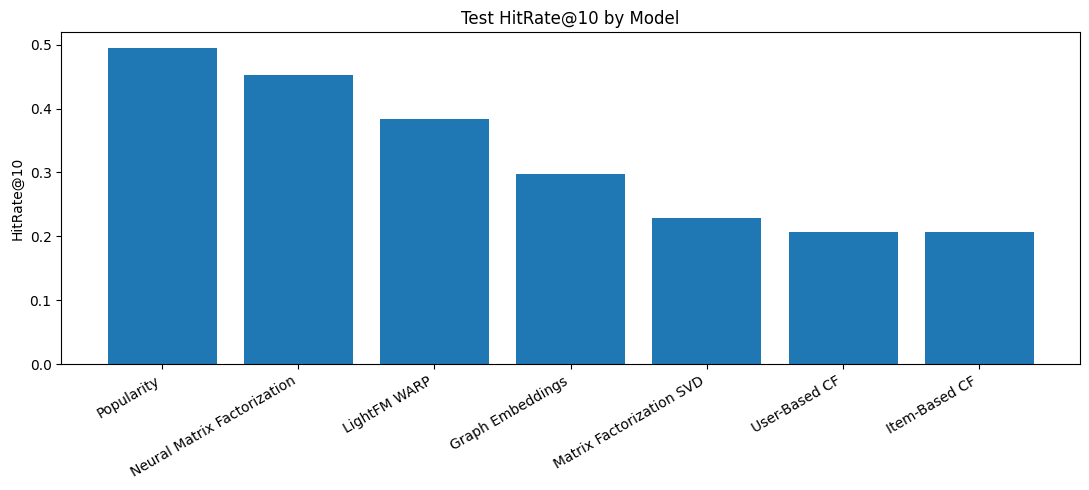

In [ ]:
plot_df = compact_test_results[["Model", "HitRate@10", "NDCG@10", "MRR@10"]].copy()

plt.figure(figsize=(11, 5))
plt.bar(plot_df["Model"], plot_df["HitRate@10"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("HitRate@10")
plt.title("Test HitRate@10 by Model")
plt.tight_layout()
plt.show()

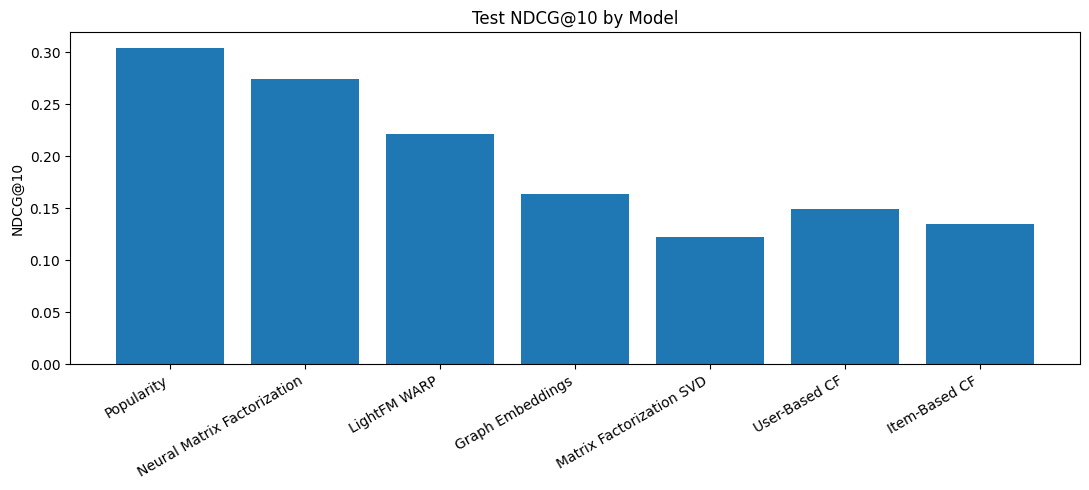

In [ ]:
plt.figure(figsize=(11, 5))
plt.bar(plot_df["Model"], plot_df["NDCG@10"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("NDCG@10")
plt.title("Test NDCG@10 by Model")
plt.tight_layout()
plt.show()

save final results with LightFM

In [ ]:
fair_val_results_df.to_csv(
    os.path.join(RESULTS_DIR, "fair_final_validation_results_with_lightfm.csv"),
    index=False
)

fair_test_results_df.to_csv(
    os.path.join(RESULTS_DIR, "fair_final_test_results_with_lightfm.csv"),
    index=False
)

print("Saved LightFM final results:")
print(os.listdir(RESULTS_DIR))

Saved LightFM final results:
['final_test_results.csv', 'validation_results_step1.csv', 'fair_final_validation_results.csv', 'validation_results_step2.csv', 'fair_final_validation_results_with_lightfm.csv', 'fair_final_test_results.csv', 'test_results_step1.csv', 'compact_fair_test_results_with_lightfm.csv', 'test_results_step2.csv', 'final_validation_results.csv', 'compact_fair_test_results.csv', 'fair_final_test_results_with_lightfm.csv']


Model 8 LightFM BPR variant

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


train LightFM with BPR

In [ ]:
lightfm_bpr_model = LightFM(
    no_components=32,
    loss="bpr",
    learning_rate=0.05,
    item_alpha=1e-6,
    user_alpha=1e-6,
    random_state=SEED
)

print("Training LightFM BPR...")

lightfm_bpr_model.fit(
    lightfm_train_matrix,
    epochs=30,
    num_threads=4,
    verbose=True
)

print("LightFM BPR training complete.")

lightfm_bpr_scorer = LightFMScorer(lightfm_bpr_model)

Training LightFM BPR...


Epoch: 100%|██████████| 30/30 [00:00<00:00, 102.38it/s]

LightFM BPR training complete.


evaluate LightFM BPR

In [ ]:
lightfm_bpr_val_results = evaluate_model(
    score_function=lightfm_bpr_scorer.score,
    eval_cases=val_cases,
    k_values=[5, 10, 20],
    model_name="LightFM BPR",
    seed=SEED
)

lightfm_bpr_test_results = evaluate_model(
    score_function=lightfm_bpr_scorer.score,
    eval_cases=test_cases,
    k_values=[5, 10, 20],
    model_name="LightFM BPR",
    seed=SEED
)

display(pd.DataFrame([lightfm_bpr_val_results]))
display(pd.DataFrame([lightfm_bpr_test_results]))

,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,LightFM BPR,0.151335,0.030267,0.151335,0.093555,0.07458,0.250247,0.025025,0.250247,0.124975,0.087217,0.41543,0.020772,0.41543,0.166472,0.09848


,Model,HitRate@5,Precision@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Precision@20,Recall@20,NDCG@20,MRR@20
0,LightFM BPR,0.131403,0.026281,0.131403,0.07886,0.061618,0.224944,0.022494,0.224944,0.108854,0.073839,0.376392,0.01882,0.376392,0.146634,0.083935


Interactive Recommender Demo

install/import widgets

In [ ]:
%pip install ipywidgets

In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output, HTML
    print("ipywidgets available")
except ImportError:
    print("Run this cell first:")
    print("%pip install ipywidgets")

ipywidgets available


prepare metadata lookup

In [ ]:
# Make sure item_idx is integer
meta_df["item_idx"] = meta_df["item_idx"].astype(int)

# Metadata lookup by item_idx
item_metadata = meta_df.set_index("item_idx").to_dict(orient="index")

def get_item_info(item_idx):
    item_idx = int(item_idx)
    info = item_metadata.get(item_idx, {})

    title = info.get("title", "Unknown title")
    category = info.get("main_category", "Unknown category")
    avg_rating = info.get("average_rating", np.nan)
    rating_number = info.get("rating_number", np.nan)
    price = info.get("price", np.nan)

    return {
        "item_idx": item_idx,
        "title": title,
        "category": category,
        "average_rating": avg_rating,
        "rating_number": rating_number,
        "price": price
    }


print("Metadata lookup ready.")
print("Metadata items:", len(item_metadata))

Metadata lookup ready.
Metadata items: 1908


define recommendation function

In [ ]:
def recommend_for_user(
    user_idx,
    score_function,
    train_user_items,
    all_items,
    top_n=10
):
    user_idx = int(user_idx)

    seen_items = train_user_items.get(user_idx, set())
    candidate_items = list(all_items - seen_items)

    if len(candidate_items) == 0:
        return pd.DataFrame()

    scores = score_function(user_idx, candidate_items)

    rec_df = pd.DataFrame({
        "item_idx": candidate_items,
        "score": scores
    })

    rec_df = rec_df.sort_values("score", ascending=False).head(top_n)

    rows = []
    for row in rec_df.itertuples(index=False):
        info = get_item_info(row.item_idx)
        rows.append({
            "Rank": len(rows) + 1,
            "Item ID": row.item_idx,
            "Title": info["title"],
            "Category": info["category"],
            "Average Rating": info["average_rating"],
            "Rating Count": info["rating_number"],
            "Price": info["price"],
            "Model Score": float(row.score)
        })

    return pd.DataFrame(rows)

define user history display

In [ ]:
def get_user_history(user_idx, train_df, meta_df):
    user_idx = int(user_idx)

    user_history = train_df[train_df["user_idx"] == user_idx].copy()

    if len(user_history) == 0:
        return pd.DataFrame()

    user_history = user_history.sort_values("timestamp")

    rows = []
    for row in user_history.itertuples(index=False):
        info = get_item_info(row.item_idx)
        rows.append({
            "Item ID": int(row.item_idx),
            "Title": info["title"],
            "Category": info["category"],
            "Rating": row.rating,
            "Timestamp": row.timestamp
        })

    return pd.DataFrame(rows)


def get_user_heldout_items(user_idx, val_df, test_df):
    user_idx = int(user_idx)

    rows = []

    val_rows = val_df[val_df["user_idx"] == user_idx]
    for row in val_rows.itertuples(index=False):
        info = get_item_info(row.item_idx)
        rows.append({
            "Split": "Validation",
            "Item ID": int(row.item_idx),
            "Title": info["title"],
            "Category": info["category"],
            "Rating": row.rating
        })

    test_rows = test_df[test_df["user_idx"] == user_idx]
    for row in test_rows.itertuples(index=False):
        info = get_item_info(row.item_idx)
        rows.append({
            "Split": "Test",
            "Item ID": int(row.item_idx),
            "Title": info["title"],
            "Category": info["category"],
            "Rating": row.rating
        })

    return pd.DataFrame(rows)

register available models for the demo

In [ ]:
demo_models = {
    "Popularity": pop_model.score,
    "Item-Based CF": itemcf_model.score,
    "User-Based CF": usercf_model.score,
    "Matrix Factorization SVD": svd_model.score,
    "Neural Matrix Factorization": neural_scorer.score,
    "Graph Embeddings": graph_model.score,
}

# Add BPR/LightFM-style model only if you implemented it
try:
    demo_models["LightFM-style BPR MF"] = bpr_scorer.score
except NameError:
    pass

# Add real LightFM only if it worked
try:
    demo_models["LightFM WARP"] = lightfm_scorer.score
except NameError:
    pass

print("Models available for demo:")
for model_name in demo_models:
    print("-", model_name)

Models available for demo:
- Popularity
- Item-Based CF
- User-Based CF
- Matrix Factorization SVD
- Neural Matrix Factorization
- Graph Embeddings
- LightFM WARP


choose good demo users

In [ ]:
user_history_counts = train_df["user_idx"].value_counts()

demo_user_candidates = (
    user_history_counts[user_history_counts >= 2]
    .sort_values(ascending=False)
    .index
    .astype(int)
    .tolist()
)

print("Demo users available:", len(demo_user_candidates))
print("Top 10 demo user candidates:", demo_user_candidates[:10])

Demo users available: 466
Top 10 demo user candidates: [1560, 450, 360, 324, 1150, 829, 241, 1103, 72, 2111]


simple non-interactive demo first

In [ ]:
demo_user = demo_user_candidates[0]
demo_model_name = "Neural Matrix Factorization"

print("Demo user:", demo_user)
print("Demo model:", demo_model_name)

print("\nUser training history:")
display(get_user_history(demo_user, train_df, meta_df))

print("\nHeld-out validation/test items:")
display(get_user_heldout_items(demo_user, val_df, test_df))

print("\nTop recommendations:")
demo_recs = recommend_for_user(
    user_idx=demo_user,
    score_function=demo_models[demo_model_name],
    train_user_items=train_user_items,
    all_items=all_items,
    top_n=10
)

display(demo_recs)

Demo user: 1560
Demo model: Neural Matrix Factorization

User training history:


,Item ID,Title,Category,Rating,Timestamp
0,1571,NinaQueen Shy Hedgehog 925 Sterling Silver Cub...,AMAZON FASHION,5.0,1487041732000
1,1557,NinaQueen Raccoon 925 Sterling Silver Cubic-Zi...,AMAZON FASHION,5.0,1489694421000
2,1543,NinaQueen Skiing Owl 925 Sterling Silver Multi...,AMAZON FASHION,5.0,1489695826000
3,1071,"NinaQueen ""Roman Holiday"" 925 Sterling Silver ...",AMAZON FASHION,5.0,1489696518000
4,781,NinaQueen Flower Queen 925 Sterling Silver Gol...,AMAZON FASHION,5.0,1489697092000
5,778,Ninaqueen 925 Sterling Silver Heart-shaped Hol...,AMAZON FASHION,5.0,1489697715000
6,1037,NINAQUEEN Celtic Tattoos 925 Sterling Silver B...,AMAZON FASHION,5.0,1489700803000
7,1550,NinaQueen Princess Bear 925 Sterling Silver En...,AMAZON FASHION,5.0,1489798769000
8,1512,NINAQUEEN Eagle of Freedom Charms Fits Charms ...,AMAZON FASHION,5.0,1490133726000
9,1015,"NinaQueen ""Blue Ripple"" 925 Sterling Silver Be...",AMAZON FASHION,5.0,1490133852000



Held-out validation/test items:


,Split,Item ID,Title,Category,Rating
0,Validation,775,"NinaQueen ""Star Pave"" 925 Sterling Silver Purp...",AMAZON FASHION,5.0
1,Test,783,NinaQueen Sweet Elephant 925 Sterling Silver G...,AMAZON FASHION,5.0



Top recommendations:


,Rank,Item ID,Title,Category,Average Rating,Rating Count,Price,Model Score
0,1,405,Vintage Style Tribal Gray Enamel Leaf Cluster ...,AMAZON FASHION,3.9,463,NaN,0.771900
1,2,398,Qiyun (TM) Luxury Purple Shell Like Oval Bead ...,AMAZON FASHION,4.2,371,NaN,0.728627
2,3,436,QIYUN.Z Geometric Oil Drop Silver Chain Tribal...,AMAZON FASHION,3.9,102,NaN,0.725256
3,4,407,Qiyun (TM) Angel's Wing Green Fringe Dangle Cr...,AMAZON FASHION,3.5,195,NaN,0.723854
4,5,430,Qiyun (TM) Acrylic Royal Blue Black Tibet Silv...,AMAZON FASHION,3.7,267,NaN,0.723717
5,6,714,Fashion Brand 925 Sterling Silver Heart Love C...,AMAZON FASHION,3.8,815,NaN,0.721112
6,7,397,Colorful Flower Cluster Festoon Y-Necklace Bib...,AMAZON FASHION,3.8,93,NaN,0.717065
7,8,396,Fashion Green Enamel Bib Link Plaque Dangle St...,AMAZON FASHION,3.8,199,NaN,0.712851
8,9,439,Qiyun (TM) Hollow Out Butterfly Antique Silver...,AMAZON FASHION,3.6,183,NaN,0.712768
9,10,403,Tribal Tibet Silver Grape Cluster Scale Pendan...,AMAZON FASHION,4.1,300,NaN,0.709048


Interactive Demo

create interactive widget demo

In [ ]:
user_dropdown = widgets.Dropdown(
    options=demo_user_candidates[:100],
    value=demo_user_candidates[0],
    description="User:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="300px")
)

model_dropdown = widgets.Dropdown(
    options=list(demo_models.keys()),
    value="Neural Matrix Factorization" if "Neural Matrix Factorization" in demo_models else list(demo_models.keys())[0],
    description="Model:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="350px")
)

topn_slider = widgets.IntSlider(
    value=10,
    min=5,
    max=20,
    step=5,
    description="Top-N:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="300px")
)

run_button = widgets.Button(
    description="Generate Recommendations",
    button_style="success",
    tooltip="Click to generate recommendations",
    icon="search"
)

output_area = widgets.Output()


def run_demo(button):
    with output_area:
        clear_output()

        selected_user = int(user_dropdown.value)
        selected_model = model_dropdown.value
        top_n = int(topn_slider.value)

        print("=" * 90)
        print("Neural Recommendations Across Marketplaces — Demo")
        print("=" * 90)
        print(f"Selected user: {selected_user}")
        print(f"Selected model: {selected_model}")
        print(f"Top-N recommendations: {top_n}")

        history_df = get_user_history(selected_user, train_df, meta_df)
        heldout_df = get_user_heldout_items(selected_user, val_df, test_df)

        print("\nUser training history:")
        if len(history_df) == 0:
            print("No training history found.")
        else:
            display(history_df)

        print("\nHeld-out future items:")
        if len(heldout_df) == 0:
            print("No validation/test item available for this user.")
        else:
            display(heldout_df)

        print("\nRecommended products:")
        recs_df = recommend_for_user(
            user_idx=selected_user,
            score_function=demo_models[selected_model],
            train_user_items=train_user_items,
            all_items=all_items,
            top_n=top_n
        )

        if len(recs_df) == 0:
            print("No recommendations generated.")
        else:
            display(recs_df)


run_button.on_click(run_demo)

display(
    widgets.VBox([
        widgets.HTML("<h2>Marketplace Recommendation Demo</h2>"),
        widgets.HTML("<p>Select a user and model to generate personalized product recommendations.</p>"),
        widgets.HBox([user_dropdown, model_dropdown, topn_slider]),
        run_button,
        output_area
    ])
)

nicer HTML product cards

product-card renderer

In [ ]:
def render_recommendation_cards(recs_df):
    html = """
    <style>
    .rec-card {
        border: 1px solid #ddd;
        border-radius: 10px;
        padding: 12px;
        margin: 10px 0;
        background-color: #fafafa;
    }
    .rec-title {
        font-size: 16px;
        font-weight: bold;
        color: #222;
    }
    .rec-meta {
        color: #555;
        font-size: 13px;
        margin-top: 4px;
    }
    .rec-score {
        color: #111;
        font-size: 13px;
        margin-top: 6px;
    }
    </style>
    """

    for row in recs_df.itertuples(index=False):
        price = row.Price
        if pd.isna(price):
            price_text = "N/A"
        else:
            price_text = f"${price}"

        html += f"""
        <div class="rec-card">
            <div class="rec-title">#{row.Rank}: {row.Title}</div>
            <div class="rec-meta">
                Category: {row.Category} |
                Avg Rating: {row._5} |
                Rating Count: {row._6} |
                Price: {price_text}
            </div>
            <div class="rec-score">
                Item ID: {row._2} |
                Model Score: {row._8:.4f}
            </div>
        </div>
        """

    display(HTML(html))

In [ ]:
def render_recommendation_cards(recs_df):
    html = """
    <style>
    .rec-card {
        border: 1px solid #ddd;
        border-radius: 10px;
        padding: 12px;
        margin: 10px 0;
        background-color: #fafafa;
    }
    .rec-title {
        font-size: 16px;
        font-weight: bold;
        color: #222;
    }
    .rec-meta {
        color: #555;
        font-size: 13px;
        margin-top: 4px;
    }
    .rec-score {
        color: #111;
        font-size: 13px;
        margin-top: 6px;
    }
    </style>
    """

    for _, row in recs_df.iterrows():
        price = row["Price"]
        if pd.isna(price):
            price_text = "N/A"
        else:
            price_text = f"${price}"

        html += f"""
        <div class="rec-card">
            <div class="rec-title">#{row["Rank"]}: {row["Title"]}</div>
            <div class="rec-meta">
                Category: {row["Category"]} |
                Avg Rating: {row["Average Rating"]} |
                Rating Count: {row["Rating Count"]} |
                Price: {price_text}
            </div>
            <div class="rec-score">
                Item ID: {row["Item ID"]} |
                Model Score: {row["Model Score"]:.4f}
            </div>
        </div>
        """

    display(HTML(html))

polished demo with product cards

In [ ]:
card_output_area = widgets.Output()

card_user_dropdown = widgets.Dropdown(
    options=demo_user_candidates[:100],
    value=demo_user_candidates[0],
    description="User:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="300px")
)

card_model_dropdown = widgets.Dropdown(
    options=list(demo_models.keys()),
    value="Neural Matrix Factorization" if "Neural Matrix Factorization" in demo_models else list(demo_models.keys())[0],
    description="Model:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="350px")
)

card_topn_slider = widgets.IntSlider(
    value=10,
    min=5,
    max=20,
    step=5,
    description="Top-N:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="300px")
)

card_run_button = widgets.Button(
    description="Run Polished Demo",
    button_style="info",
    icon="shopping-bag"
)


def run_card_demo(button):
    with card_output_area:
        clear_output()

        selected_user = int(card_user_dropdown.value)
        selected_model = card_model_dropdown.value
        top_n = int(card_topn_slider.value)

        display(HTML(f"""
        <h2>Neural Recommendations Across Marketplaces</h2>
        <h3>Demo Output</h3>
        <p><b>User:</b> {selected_user}</p>
        <p><b>Model:</b> {selected_model}</p>
        """))

        history_df = get_user_history(selected_user, train_df, meta_df)
        heldout_df = get_user_heldout_items(selected_user, val_df, test_df)

        display(HTML("<h3>User Training History</h3>"))
        display(history_df)

        display(HTML("<h3>Held-Out Future Items</h3>"))
        if len(heldout_df) > 0:
            display(heldout_df)
        else:
            display(HTML("<p>No held-out items found for this user.</p>"))

        recs_df = recommend_for_user(
            user_idx=selected_user,
            score_function=demo_models[selected_model],
            train_user_items=train_user_items,
            all_items=all_items,
            top_n=top_n
        )

        display(HTML("<h3>Recommended Products</h3>"))
        render_recommendation_cards(recs_df)


card_run_button.on_click(run_card_demo)

display(
    widgets.VBox([
        widgets.HTML("<h2>Polished Product Recommendation Demo</h2>"),
        widgets.HBox([card_user_dropdown, card_model_dropdown, card_topn_slider]),
        card_run_button,
        card_output_area
    ])
)